Notebook demonstrating how ODE simulations and linear framework solutions can have similar outputs for the Kinetic Proofreading model (STAT3)

In [1]:
from pysb import Model, Parameter, Compartment, Monomer, Parameter, Rule, Initial, Observable
from pysb.simulator import ScipyOdeSimulator
import numpy as np
import cython
import matplotlib.pyplot as plt
import sympy as sp
import pickle
from collections import Counter
import sys, os
from src.PySBtoLF_func import generate_graphs,adapt_graph_get_rhos
from time import time
from scipy.optimize import least_squares

In [2]:
def func_time(IL10):
    if IL10 > 1e-7:
        return 0.1*5,1e4
    else:
        IL10 = abs(np.log10(IL10)) - 3
        return 10**(IL10)/(1e4)*5,10**(IL10)

PA={
    "vol_EC" : 1.0E-10, # In dm # OG: 1.0E-10
    "surf_cell" : 1.11545244e-07, # OG: 1.4e-08 Mut_noSOCS: 1.4e-7
    "vol_cell" : 3.0E-12, # In dm
    "k_ILM_f" : 6.97E+05,
    "k_ILM_b" : 3.07214605e+00, #4.34 # OG: 4.34e-02 Mut_noSOCS: 8.34e-02
    "k_IL_RA_f" : 6.97E+05,
    "k_IL_RA_b" : 5.94742574e-04, # OG: 1.42E-04 Mut_noSOCS: 1.42E-03
    "k_IL_RB_f" : 6.97E+05,
    "k_IL_RB_b" : 1394, # OG: 1394
    "k_IL_RA_RB_f" : 6.97E+05,
    "k_IL_RA_RB_b" : 1.32365577e+00, # OG: 243.95
    "k_STAT1_f" : 6.55E+06*10,
    "k_STAT1_b" : 0.678,
    "k_M_f" : 6.55E+06*1000,
    "k_M_b" : 0.678,
    "k_STAT3_f" : 6.55E+06*1000,
    "k_STAT3_b" : 0.678,
    "k_PHOS" : 3.16E-03,
    "k_DEPHOS" : 0.000664996232095083
}

IC = {
    "IL0":1e-7,
    "RA0":750,
    "RB0":2323,
    "STAT10" : 477858.2479731492,
    "M0" : 477858.2479731492,
    "STAT30" : 477858.2479731492
    }

First we generate the full model with STAT3 binding to a single site in RA to have less dependancy on RB binding (Kinetic proofreading)

In [3]:
PA_WT={
    "vol_EC" : 1.0E-10, # In dm # OG: 1.0E-10
    "surf_cell" : 1.11545244e-07, # OG: 1.4e-08 Mut_noSOCS: 1.4e-7
    "vol_cell" : 3.0E-12, # In dm
    "k_ILM_f" : 6.97E+05,
    "k_ILM_b" : 3.07214605e+00, #4.34 # OG: 4.34e-02 Mut_noSOCS: 8.34e-02
    "k_IL_RA_f" : 6.97E+05,
    "k_IL_RA_b" : 5.94742574e-04, # OG: 1.42E-04 Mut_noSOCS: 1.42E-03
    "k_IL_RB_f" : 6.97E+05*10000,
    "k_IL_RB_b" : 1394*1000, # OG: 1394
    "k_IL_RA_RB_f" : 6.97E+05*10000,
    "k_IL_RA_RB_b" : 1.32365577e+00*1000, # OG: 243.95
    "k_STAT1_f" : 6.55E+06*1000/10,
    "k_STAT1_b" : 0.678/1000000,
    "k_M_f" : 6.55E+06*10/10,
    "k_M_b" : 0.678/1000000,
    "k_STAT3_f" : 6.55E+06*10000,
    "k_STAT3_b" : 0.678*1000,
    "k_PHOS" : 3.16E-03*5000,
    "k_DEPHOS" : 0.000664996232095083
}
PA_mut={
    "vol_EC" : 1.0E-10, # In dm # OG: 1.0E-10
    "surf_cell" : 1.11545244e-07, # OG: 1.4e-08 Mut_noSOCS: 1.4e-7
    "vol_cell" : 3.0E-12, # In dm
    "k_ILM_f" : 6.97E+05,
    "k_ILM_b" : 3.07214605e+00, #4.34 # OG: 4.34e-02 Mut_noSOCS: 8.34e-02
    "k_IL_RA_f" : 6.97E+05,
    "k_IL_RA_b" : 5.94742574e-04, # OG: 1.42E-04 Mut_noSOCS: 1.42E-03
    "k_IL_RB_f" : 6.97E+05*100000,
    "k_IL_RB_b" : 1394*1000, # OG: 1394
    "k_IL_RA_RB_f" : 6.97E+05*100000,
    "k_IL_RA_RB_b" : 1.32365577e+00*1000, # OG: 243.95
    "k_STAT1_f" : 6.55E+06*1000/10,
    "k_STAT1_b" : 0.678/1000000,
    "k_M_f" : 6.55E+06*10/10,
    "k_M_b" : 0.678/1000000,
    "k_STAT3_f" : 6.55E+06*10000,
    "k_STAT3_b" : 0.678*1000,
    "k_PHOS" : 3.16E-03*5000,
    "k_DEPHOS" : 0.000664996232095083
}

In [4]:
def model_func_full(PA,IC):
    Na=6.023e23
    Width_PM = 1e-7 # In dm
    # Initialize model
    Model()
    
    # Compartment
    Compartment(name='EC', parent=None, dimension=3, size=None)
    Compartment(name='Cell_PM', parent=EC, dimension=2, size=None)
    Compartment(name='Cell_CP', parent=Cell_PM, dimension=3, size=None)
    
    # Monomers
    Monomer('ILM')
    Monomer('IL', ['bA1', 'bA2', 'bB1', 'bB2','B_t'], {'B_t': ['QB','TB','DB','SB','U']})
    Monomer('RA', ['bA', 'bSTAT3'])
    Monomer('RB', ['bB'])
    Monomer('STAT3', ['b3','P'], {'P': ['u', 'p']})
    
    # Parameters (We put whatever number)
    Parameter('K_ILM_f', PA["k_ILM_f"]/(Na*PA["vol_EC"])*2)
    Parameter('K_ILM_b', PA["k_ILM_b"])
    
    Parameter('K_IL_RA_f', PA["k_IL_RA_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RA_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB_f', PA["k_IL_RB_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RB_b', PA["k_IL_RB_b"])
    
    Parameter('K_IL_RA2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA2_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB2_f', PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RB2_b', PA["k_IL_RB_b"])
    Parameter('K_IL_RA_RB_f', PA["k_IL_RA_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA_RB_b', PA["k_IL_RA_RB_b"])

    Parameter('K_STAT3_f', PA["k_STAT3_f"]/(Na*PA["vol_cell"]))
    Parameter('K_STAT3_b', PA["k_STAT3_b"])
    Parameter('K_PHOS', PA["k_PHOS"])   
    Parameter('K_DEPHOS', PA["k_DEPHOS"])
    
    # Complexes and reactions (binding of receptors)
    IL_free = IL(bA1=None, bA2=None, bB1=None, bB2=None, B_t='U')
    ILM_free = ILM()
    Rule('IL_binding', ILM_free + ILM_free | IL_free, *[K_ILM_f, K_ILM_b])
    
    # Binding of 1st receptor
    IL_RA1_alone = IL(bA1=1, bA2=None, bB1=None, bB2=None, B_t='SB') % RA(bA=1, bSTAT3=None)
    Rule('IL_RA1_alone_binding', IL_free + RA(bA=None, bSTAT3=None)| IL_RA1_alone, *[K_IL_RA_f, K_IL_RA_b])
    IL_RA2_alone = IL(bA1=None, bA2=2, bB1=None, bB2=None, B_t='SB') % RA(bA=2, bSTAT3=None)
    Rule('IL_RA2_alone_binding', IL_free + RA(bA=None, bSTAT3=None) | IL_RA2_alone, *[K_IL_RA_f, K_IL_RA_b])
    IL_RB1_alone = IL(bA1=None, bA2=None, bB1=3, bB2=None, B_t='SB') % RB(bB=3)
    Rule('IL_RB1_binding_alone', IL_free + RB(bB=None) | IL_RB1_alone, *[K_IL_RB_f, K_IL_RB_b])
    IL_RB2_alone = IL(bA1=None, bA2=None, bB1=None, bB2=4, B_t='SB') % RB(bB=4)
    Rule('IL_RB2_binding_alone', IL_free + RB(bB=None) | IL_RB2_alone, *[K_IL_RB_f, K_IL_RB_b])
    
    # Binding of 2nd receptor
    IL_RA1_RB1_DB = IL(bA1=1, bA2=None, bB1=3, bB2=None, B_t='DB') % RA(bA=1, bSTAT3=None) % RB(bB=3)
    Rule('IL_RA1_wRB1_binding_DB', IL_RB1_alone + RA(bA=None, bSTAT3=None) | IL_RA1_RB1_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RA1_RB1_S3_DB = IL(bA1=1, bA2=None, bB1=2, bB2=None, B_t='DB') % RA(bA=1, bSTAT3=5) % RB(bB=2) % STAT3(b3=5, P='u')
    Rule('IL_RA1_wRB1_unbinding_DB', IL_RA1_RB1_S3_DB >> IL_RB1_alone + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    IL_noRA1_noRB1_SB = IL(bA1=None, bB1=None, B_t='SB')
    IL_RA1_noRB1_DB = IL(bA1=1, bB1=None, B_t='DB') % RA(bA=1, bSTAT3=None) 
    Rule('IL_RA1_noRB1_binding_DB', IL_noRA1_noRB1_SB + RA(bA=None, bSTAT3=None) | IL_RA1_noRB1_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_RA2_RB2_DB = IL(bA1=None, bA2=2, bB1=None, bB2=4, B_t='DB') % RA(bA=2, bSTAT3=None) % RB(bB=4)
    Rule('IL_RA2_wRB2_binding_DB', IL_RB2_alone + RA(bA=None, bSTAT3=None) | IL_RA2_RB2_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RA2_RB2_S3_DB = IL(bA1=None, bA2=2, bB1=None, bB2=4, B_t='DB') % RA(bA=2, bSTAT3=6) % RB(bB=4) % STAT3(b3=6, P='u')
    Rule('IL_RA2_wRB2_unbinding_DB', IL_RA2_RB2_S3_DB >> IL_RB2_alone + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    IL_noRA2_noRB2_SB = IL(bA2=None, bB2=None, B_t='SB')
    IL_RA2_noRB2_DB = IL(bA2=2, bB2=None, B_t='DB') % RA(bA=2, bSTAT3=None) 
    Rule('IL_RA2_noRB2_binding_DB', IL_noRA2_noRB2_SB + RA(bA=None, bSTAT3=None) | IL_RA2_noRB2_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_noRA1_RB1_DB = IL(bA1=None, bB1=3, B_t='DB') % RB(bB=3)
    Rule('IL_noRA1_RB1_binding_DB', IL_noRA1_noRB1_SB + RB(bB=None) | IL_noRA1_RB1_DB, *[K_IL_RB2_f, K_IL_RB2_b])
    Rule('IL_wRA1_RB1_binding_DB', IL_RA1_alone + RB(bB=None) | IL_RA1_RB1_DB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_wRA1_RB1_unbinding_DB', IL_RA1_RB1_S3_DB >> IL_RA1_alone + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)

    IL_noRA2_RB2_DB = IL(bA2=None, bB2=4, B_t='DB') % RB(bB=4)
    Rule('IL_noRA2_RB2_binding_DB', IL_noRA2_noRB2_SB + RB(bB=None) | IL_noRA2_RB2_DB, *[K_IL_RB2_f, K_IL_RB2_b])
    Rule('IL_wRA2_RB2_binding_DB', IL_RA2_alone + RB(bB=None) | IL_RA2_RB2_DB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_wRA2_RB2_unbinding_DB', IL_RA2_RB2_S3_DB >> IL_RA2_alone + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)

    
    # Binding of 3rd receptor
    IL_noRA1_RB1_DB = IL(bA1=None, bB1=3, B_t='DB') % RB(bB=3)
    IL_RA1_RB1_TB = IL(bA1=1, bB1=3, B_t='TB') % RA(bA=1, bSTAT3=None) % RB(bB=3)
    Rule('IL_RA1_wRB1_binding_TB', IL_noRA1_RB1_DB + RA(bA=None, bSTAT3=None) | IL_RA1_RB1_TB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RA1_RB1_S3_TB = IL(bA1=1, bB1=2, B_t='TB') % RA(bA=1, bSTAT3=5) % RB(bB=2) % STAT3(b3=5, P='u')
    Rule('IL_RA1_wRB1_unbinding_TB', IL_RA1_RB1_S3_TB >> IL_noRA1_RB1_DB + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    IL_noRA1_noRB1_DB = IL(bA1=None, bB1=None, B_t='DB')
    IL_RA1_noRB1_TB = IL(bA1=1, bB1=None, B_t='TB') % RA(bA=1, bSTAT3=None) 
    Rule('IL_RA1_noRB1_binding_TB', IL_noRA1_noRB1_DB + RA(bA=None, bSTAT3=None) | IL_RA1_noRB1_TB, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_noRA2_RB2_DB = IL(bA2=None, bB2=4, B_t='DB') % RB(bB=4)
    IL_RA2_RB2_TB = IL(bA2=2, bB2=4, B_t='TB') % RA(bA=2, bSTAT3=None) % RB(bB=4)
    Rule('IL_RA2_wRB2_binding_TB', IL_noRA2_RB2_DB + RA(bA=None, bSTAT3=None) | IL_RA2_RB2_TB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RA2_RB2_S3_TB = IL(bA2=2, bB2=4, B_t='TB') % RA(bA=2, bSTAT3=6) % RB(bB=4) % STAT3(b3=6, P='u')
    Rule('IL_RA2_wRB2_unbinding_TB', IL_RA2_RB2_S3_TB >> IL_noRA2_RB2_DB + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    IL_noRA2_noRB2_DB = IL(bA2=None, bB2=None, B_t='DB')
    IL_RA2_noRB2_TB = IL(bA2=2, bB2=None, B_t='TB') % RA(bA=2, bSTAT3=None) 
    Rule('IL_RA2_noRB2_binding_TB', IL_noRA2_noRB2_DB + RA(bA=None, bSTAT3=None) | IL_RA2_noRB2_TB, *[K_IL_RA2_f, K_IL_RA2_b])

    IL_noRA1_RB1_TB = IL(bA1=None, bB1=3, B_t='TB') % RB(bB=3)
    Rule('IL_noRA1_RB1_binding_TB', IL_noRA1_noRB1_DB + RB(bB=None) | IL_noRA1_RB1_TB, *[K_IL_RB2_f, K_IL_RB2_b])
    IL_RA1_noRB1_DB = IL(bA1=1, bB1=None, B_t='DB') % RA(bA=1, bSTAT3=None)
    Rule('IL_wRA1_RB1_binding_TB', IL_RA1_noRB1_DB + RB(bB=None) | IL_RA1_RB1_TB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_wRA1_RB1_unbinding_TB', IL_RA1_RB1_S3_TB >> IL_RA1_noRB1_DB + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)

    IL_noRA2_RB2_TB = IL(bA2=None, bB2=4, B_t='TB') % RB(bB=4)
    Rule('IL_noRA2_RB2_binding_TB', IL_noRA2_noRB2_DB + RB(bB=None) | IL_noRA2_RB2_TB, *[K_IL_RB2_f, K_IL_RB2_b])
    IL_RA2_noRB2_DB = IL(bA2=2, bB2=None, B_t='DB') % RA(bA=2, bSTAT3=None)
    Rule('IL_wRA2_RB2_binding_TB', IL_RA2_noRB2_DB + RB(bB=None) | IL_RA2_RB2_TB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_wRA2_RB2_unbinding_TB', IL_RA2_RB2_S3_TB >> IL_RA2_noRB2_DB + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)

    
    # Binding of 4th receptor
    IL_RA1_RA2_RB1_RB2 = IL(bA1=1, bA2=2, bB1=3, bB2=4, B_t='QB') % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=None) % RB(bB=3) % RB(bB=4)
    IL_RA1_RA2_RB1_RB2_S31 = IL(bA1=1, bA2=2, bB1=3, bB2=4, B_t='QB') % RA(bA=1, bSTAT3=5) % RA(bA=2, bSTAT3=None) % RB(bB=3) % RB(bB=4) % STAT3(b3=5, P='u')
    IL_RA1_RA2_RB1_RB2_S32 = IL(bA1=1, bA2=2, bB1=3, bB2=4, B_t='QB') % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=6) % RB(bB=3) % RB(bB=4) % STAT3(b3=6, P='u')
    IL_RA1_RA2_RB1_RB2_S31_S32 = IL(bA1=1, bA2=2, bB1=3, bB2=4, B_t='QB') % RA(bA=1, bSTAT3=5) % RA(bA=2, bSTAT3=6) % RB(bB=3) % RB(bB=4) % STAT3(b3=5, P='u') % STAT3(b3=6, P='u')

    IL_noRA1_TB = IL(bA1=None, bA2=2, bB1=3, bB2=4, B_t='TB') % RA(bA=2, bSTAT3=None) % RB(bB=3) % RB(bB=4)
    IL_noRA1_TB_S32 = IL(bA1=None, bA2=2, bB1=3, bB2=4, B_t='TB') % RA(bA=2, bSTAT3=6) % RB(bB=3) % RB(bB=4) % STAT3(b3=6, P='u')
    Rule('IL_RA1_binding_fin', IL_noRA1_TB + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RA1_binding_fin2', IL_noRA1_TB_S32 + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1_RB2_S32, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RA1_unbinding_fin1', IL_RA1_RA2_RB1_RB2_S31 >> IL_noRA1_TB + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    Rule('IL_RA1_unbinding_fin2', IL_RA1_RA2_RB1_RB2_S31_S32 >> IL_noRA1_TB_S32 + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)

    IL_noRA2_TB = IL(bA1=1, bA2=None, bB1=3, bB2=4, B_t='TB') % RA(bA=1, bSTAT3=None) % RB(bB=3) % RB(bB=4)
    IL_noRA2_TB_S31 = IL(bA1=1, bA2=None, bB1=3, bB2=4, B_t='TB') % RA(bA=1, bSTAT3=5) % RB(bB=3) % RB(bB=4) % STAT3(b3=5, P='u')
    Rule('IL_RA2_binding_fin', IL_noRA2_TB + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RA2_binding_fin2', IL_noRA2_TB_S31 + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1_RB2_S31, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RA2_unbinding_fin1', IL_RA1_RA2_RB1_RB2_S32 >> IL_noRA2_TB + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    Rule('IL_RA2_unbinding_fin2', IL_RA1_RA2_RB1_RB2_S31_S32 >> IL_noRA2_TB_S31 + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)

    IL_noRB1_TB = IL(bA1=1, bA2=2, bB1=None, bB2=4, B_t='TB') % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=None) % RB(bB=4)
    IL_noRB1_TB_S32 = IL(bA1=1, bA2=2, bB1=None, bB2=4, B_t='TB') % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=6) % RB(bB=4) % STAT3(b3=6, P='u')
    Rule('IL_RB1_binding_fin', IL_noRB1_TB + RB(bB=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_RB1_binding_fin2', IL_noRB1_TB_S32 + RB(bB=None) | IL_RA1_RA2_RB1_RB2_S32, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_RB1_unbinding_fin1', IL_RA1_RA2_RB1_RB2_S31 >> IL_noRB1_TB + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)
    Rule('IL_RB1_unbinding_fin2', IL_RA1_RA2_RB1_RB2_S31_S32 >> IL_noRB1_TB_S32 + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)

    IL_noRB2_TB = IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=None) % RB(bB=3)
    IL_noRB2_TB_S31 = IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') % RA(bA=1, bSTAT3=5) % RA(bA=2, bSTAT3=None) % RB(bB=3) % STAT3(b3=5, P='u')
    Rule('IL_RB2_binding_fin', IL_noRB2_TB + RB(bB=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_RB2_binding_fin2', IL_noRB2_TB_S31 + RB(bB=None) | IL_RA1_RA2_RB1_RB2_S31, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_RB2_unbinding_fin1', IL_RA1_RA2_RB1_RB2_S32 >> IL_noRB2_TB + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)
    Rule('IL_RB2_unbinding_fin2', IL_RA1_RA2_RB1_RB2_S31_S32 >> IL_noRB2_TB_S31 + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)
    
    # Binding of STAT
    IL_RA1_RB1 = IL(bA1=1, bB1=3) % RA(bA=1, bSTAT3=None) % RB(bB=3)
    IL_RA1_RB1_S31 = IL(bA1=1, bB1=3) % RA(bA=1, bSTAT3=5) % RB(bB=3) % STAT3(b3=5, P='u')
    Rule('IL_RA1_RB1_S3_binding', IL_RA1_RB1 + STAT3(b3=None, P='u') | IL_RA1_RB1_S31, *[K_STAT3_f, K_STAT3_b])
    IL_RA2_RB2 = IL(bA2=2, bB2=4) % RA(bA=2, bSTAT3=None) % RB(bB=4)
    IL_RA2_RB2_S32 = IL(bA2=2, bB2=4) % RA(bA=2, bSTAT3=6) % RB(bB=4) % STAT3(b3=6, P='u')
    Rule('IL_RA2_RB2_S3_binding', IL_RA2_RB2 + STAT3(b3=None, P='u') | IL_RA2_RB2_S32, *[K_STAT3_f, K_STAT3_b])

    Rule('IL_RA1_RB1_S3_phosphorylation', IL_RA1_RB1_S31 >> IL_RA1_RB1 + STAT3(b3=None, P='p'), K_PHOS)
    Rule('IL_RA2_RB2_S3_phosphorylation', IL_RA2_RB2_S32 >> IL_RA2_RB2 + STAT3(b3=None, P='p'), K_PHOS)
    Rule('STAT3_dephosphorilation', STAT3(b3=None, P='p') >> STAT3(b3=None, P='u'), K_DEPHOS)
    
    # Initial conditions
    Kd_IL = PA["k_ILM_b"]/(PA["k_ILM_f"]/(Na*PA["vol_EC"]))
    ILM_eq = (-Kd_IL/2 + (Kd_IL**2/4 + 2*Kd_IL*IC["IL0"]*Na*PA["vol_EC"])**(1/2))/2
    ILD_eq = (IC["IL0"]*Na*PA["vol_EC"]-ILM_eq)/2
    Parameter('ILM_0', ILM_eq)
    Initial(ILM() ** EC , ILM_0)
    Parameter('ILD_0', ILD_eq) #IC["IL0"]*Na*PA["vol_EC"])
    Initial(IL(bA1=None, bA2=None, bB1=None, bB2=None, B_t='U') ** EC, ILD_0)
    
    Parameter('RA_0',IC["RA0"])
    Parameter('RB_0',IC["RB0"])
    Initial(RA(bA=None, bSTAT3=None) ** Cell_PM, RA_0)
    Initial(RB(bB=None) ** Cell_PM, RB_0)

    Parameter('STAT_3_0', IC["STAT30"])
    Initial(STAT3(b3=None, P='u') ** Cell_CP, STAT_3_0)
    
    # Simulation
    Observable('ILM_free', ILM() ** EC)
    Observable('IL_free', IL(bA1=None, bA2=None, bB1=None, bB2=None, B_t='U') ** EC)
    Observable('RA_free', RA(bA=None, bSTAT3=None) ** Cell_PM)
    Observable('RB_free', RB(bB=None) ** Cell_PM)
    Observable('S3_free', STAT3(b3=None, P='u') ** Cell_CP)
    
    Observable('IL_RA1', IL(bA1=1, bA2=None, bB1=None, bB2=None, B_t='SB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM)
    Observable('IL_RA2', IL(bA1=None, bA2=1, bB1=None, bB2=None, B_t='SB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM)
    Observable('IL_RB1', IL(bA1=None, bA2=None, bB1=1, bB2=None, B_t='SB') ** EC % RB(bB=1) ** Cell_PM)
    Observable('IL_RB2', IL(bA1=None, bA2=None, bB1=None, bB2=1, B_t='SB') ** EC % RB(bB=1) ** Cell_PM)
    
    Observable('IL_RA1_RA2', IL(bA1=1, bA2=2, bB1=None, bB2=None, B_t='DB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM)
    Observable('IL_RA1_RB1', IL(bA1=1, bA2=None, bB1=2, bB2=None, B_t='DB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA1_RB2', IL(bA1=1, bA2=None, bB1=None, bB2=2, B_t='DB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA2_RB1', IL(bA1=None, bA2=1, bB1=2, bB2=None, B_t='DB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA2_RB2', IL(bA1=None, bA2=1, bB1=None, bB2=2, B_t='DB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RB1_RB2', IL(bA1=None, bA2=None, bB1=1, bB2=2, B_t='DB') ** EC % RB(bB=1) ** Cell_PM % RB(bB=2) ** Cell_PM)

    Observable('IL_RA1_RA2_RB1', IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1_RA2_RB2', IL(bA1=1, bA2=2, bB1=None, bB2=3, B_t='TB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1_RB1_RB2', IL(bA1=1, bA2=None, bB1=2, bB2=3, B_t='TB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA2_RB1_RB2', IL(bA1=None, bA2=1, bB1=2, bB2=3, B_t='TB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM)

    Observable('IL_RA1_RA2_RB1_RB2', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM)
    
    Observable('IL_RA1_RB1_S31', IL(bA1=1, bA2=None, bB1=2, bB2=None, B_t='DB') ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RB(bB=2) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    Observable('IL_RA2_RB2_S32', IL(bA1=None, bA2=1, bB1=None, bB2=2, B_t='DB') ** EC % RA(bA=1, bSTAT3=6) ** Cell_PM % RB(bB=2) ** Cell_PM % STAT3(b3=6, P='u') ** Cell_CP)
    
    Observable('IL_RA1_RA2_RB1_S31', IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    Observable('IL_RA1_RA2_RB2_S32', IL(bA1=1, bA2=2, bB1=None, bB2=3, B_t='TB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=6) ** Cell_PM % RB(bB=3) ** Cell_PM % STAT3(b3=6, P='u') ** Cell_CP)
    Observable('IL_RA1_RB1_RB2_S31', IL(bA1=1, bA2=None, bB1=2, bB2=3, B_t='TB') ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    Observable('IL_RA2_RB1_RB2_S32', IL(bA1=None, bA2=1, bB1=2, bB2=3, B_t='TB') ** EC % RA(bA=1, bSTAT3=6) ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM % STAT3(b3=6, P='u') ** Cell_CP)

    Observable('IL_RA1_RA2_RB1_RB2_S31', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    Observable('IL_RA1_RA2_RB1_RB2_S32', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=6) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM % STAT3(b3=6, P='u') ** Cell_CP)
    Observable('IL_RA1_RA2_RB1_RB2_S31_S32', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RA(bA=2, bSTAT3=6) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP % STAT3(b3=6, P='u') ** Cell_CP)
    
    Observable('STAT3P', STAT3(b3=None, P='p') ** Cell_CP)
    
    dT, Tf = func_time(IC["IL0"])
    t = np.arange(0,Tf,dT/500)
    simulator = ScipyOdeSimulator(model, tspan=t, compiler='python', integrator = 'lsoda').run()
    return simulator.all

In [5]:
IL_10vec = np.exp(np.linspace(np.log(1e-14), np.log(1e-6), 15))
STAT3_WT = []
STAT3_mut = []
for IL_10 in IL_10vec:
    IC = {
    "IL0":IL_10,
    "RA0":750,
    "RB0":4323,
    "STAT10" : 477858.2479731492,
    "M0" : 477858.2479731492,
    "STAT30" : 477858.2479731492
    }
    simulator = model_func_full(PA_WT,IC)
    STAT3_WT.append(simulator['STAT3P'][-1])
    del(simulator)
    simulator = model_func_full(PA_mut,IC)
    STAT3_mut.append(simulator['STAT3P'][-1])
    del(simulator)

Text(0, 0.5, 'pSTAT3')

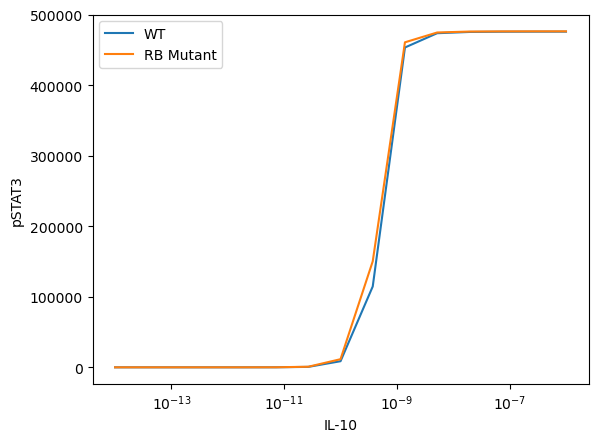

In [6]:
plt.plot(IL_10vec,STAT3_WT, label="WT")
plt.plot(IL_10vec,STAT3_mut, label="RB Mutant")
plt.legend(loc="best")
plt.xscale("log")
plt.xlabel("IL-10")
plt.ylabel("pSTAT3")

When compared to pSTAT1, pSTAT3 has a reduced dependancy on binding to IL10RB

Then we compare a model of IL10 where STAT3 binds and phosphorylates to one where STAT3 only binds to possibly simplify the model

In [7]:
PA={
    "vol_EC" : 1.0E-10, # In dm # OG: 1.0E-10
    "surf_cell" : 1.11545244e-07, # OG: 1.4e-08 Mut_noSOCS: 1.4e-7
    "vol_cell" : 3.0E-12, # In dm
    "k_ILM_f" : 6.97E+05,
    "k_ILM_b" : 3.07214605e+00, #4.34 # OG: 4.34e-02 Mut_noSOCS: 8.34e-02
    "k_IL_RA_f" : 6.97E+05,
    "k_IL_RA_b" : 5.94742574e-04, # OG: 1.42E-04 Mut_noSOCS: 1.42E-03
    "k_IL_RB_f" : 6.97E+05,
    "k_IL_RB_b" : 1394, # OG: 1394
    "k_IL_RA_RB_f" : 6.97E+05,
    "k_IL_RA_RB_b" : 1.32365577e+00, # OG: 243.95
    "k_STAT1_f" : 6.55E+06*10,
    "k_STAT1_b" : 0.678,
    "k_M_f" : 6.55E+06*1000,
    "k_M_b" : 0.678,
    "k_STAT3_f" : 6.55E+06*1000,
    "k_STAT3_b" : 0.678,
    "k_PHOS" : 3.16E-03,
    "k_DEPHOS" : 0.000664996232095083
}

In [8]:
def model_func_full_bind(PA,IC):
    Na=6.023e23
    Width_PM = 1e-7 # In dm
    # Initialize model
    Model()
    
    # Compartment
    Compartment(name='EC', parent=None, dimension=3, size=None)
    Compartment(name='Cell_PM', parent=EC, dimension=2, size=None)
    Compartment(name='Cell_CP', parent=Cell_PM, dimension=3, size=None)
    
    # Monomers
    Monomer('ILM')
    Monomer('IL', ['bA1', 'bA2', 'bB1', 'bB2','B_t'], {'B_t': ['QB','TB','DB','SB','U']})
    Monomer('RA', ['bA', 'bSTAT3'])
    Monomer('RB', ['bB'])
    Monomer('STAT3', ['b3','P'], {'P': ['u', 'p']})
    
    # Parameters (We put whatever number)
    Parameter('K_ILM_f', PA["k_ILM_f"]/(Na*PA["vol_EC"])*2)
    Parameter('K_ILM_b', PA["k_ILM_b"])
    
    Parameter('K_IL_RA_f', PA["k_IL_RA_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RA_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB_f', PA["k_IL_RB_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RB_b', PA["k_IL_RB_b"])
    
    Parameter('K_IL_RA2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA2_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB2_f', PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RB2_b', PA["k_IL_RB_b"])
    Parameter('K_IL_RA_RB_f', PA["k_IL_RA_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA_RB_b', PA["k_IL_RA_RB_b"])

    Parameter('K_STAT3_f', PA["k_STAT3_f"]/(Na*PA["vol_cell"]))
    Parameter('K_STAT3_b', PA["k_STAT3_b"])
    Parameter('K_PHOS', PA["k_PHOS"])   
    Parameter('K_DEPHOS', PA["k_DEPHOS"])
    
    # Complexes and reactions (binding of receptors)
    IL_free = IL(bA1=None, bA2=None, bB1=None, bB2=None, B_t='U')
    ILM_free = ILM()
    Rule('IL_binding', ILM_free + ILM_free | IL_free, *[K_ILM_f, K_ILM_b])

    # Binding of 1st receptor
    IL_RA1_alone = IL(bA1=1, bA2=None, bB1=None, bB2=None, B_t='SB') % RA(bA=1, bSTAT3=None)
    Rule('IL_RA1_alone_binding', IL_free + RA(bA=None, bSTAT3=None)| IL_RA1_alone, *[K_IL_RA_f, K_IL_RA_b])
    IL_RA2_alone = IL(bA1=None, bA2=2, bB1=None, bB2=None, B_t='SB') % RA(bA=2, bSTAT3=None)
    Rule('IL_RA2_alone_binding', IL_free + RA(bA=None, bSTAT3=None) | IL_RA2_alone, *[K_IL_RA_f, K_IL_RA_b])
    IL_RB1_alone = IL(bA1=None, bA2=None, bB1=3, bB2=None, B_t='SB') % RB(bB=3)
    Rule('IL_RB1_binding_alone', IL_free + RB(bB=None) | IL_RB1_alone, *[K_IL_RB_f, K_IL_RB_b])
    IL_RB2_alone = IL(bA1=None, bA2=None, bB1=None, bB2=4, B_t='SB') % RB(bB=4)
    Rule('IL_RB2_binding_alone', IL_free + RB(bB=None) | IL_RB2_alone, *[K_IL_RB_f, K_IL_RB_b])
    
    # Binding of 2nd receptor
    IL_RA1_RB1_DB = IL(bA1=1, bA2=None, bB1=3, bB2=None, B_t='DB') % RA(bA=1, bSTAT3=None) % RB(bB=3)
    Rule('IL_RA1_wRB1_binding_DB', IL_RB1_alone + RA(bA=None, bSTAT3=None) | IL_RA1_RB1_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RA1_RB1_S3_DB = IL(bA1=1, bA2=None, bB1=2, bB2=None, B_t='DB') % RA(bA=1, bSTAT3=5) % RB(bB=2) % STAT3(b3=5, P='u')
    Rule('IL_RA1_wRB1_unbinding_DB', IL_RA1_RB1_S3_DB >> IL_RB1_alone + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    IL_noRA1_noRB1_SB = IL(bA1=None, bB1=None, B_t='SB')
    IL_RA1_noRB1_DB = IL(bA1=1, bB1=None, B_t='DB') % RA(bA=1, bSTAT3=None) 
    Rule('IL_RA1_noRB1_binding_DB', IL_noRA1_noRB1_SB + RA(bA=None, bSTAT3=None) | IL_RA1_noRB1_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_RA2_RB2_DB = IL(bA1=None, bA2=2, bB1=None, bB2=4, B_t='DB') % RA(bA=2, bSTAT3=None) % RB(bB=4)
    Rule('IL_RA2_wRB2_binding_DB', IL_RB2_alone + RA(bA=None, bSTAT3=None) | IL_RA2_RB2_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RA2_RB2_S3_DB = IL(bA1=None, bA2=2, bB1=None, bB2=4, B_t='DB') % RA(bA=2, bSTAT3=6) % RB(bB=4) % STAT3(b3=6, P='u')
    Rule('IL_RA2_wRB2_unbinding_DB', IL_RA2_RB2_S3_DB >> IL_RB2_alone + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    IL_noRA2_noRB2_SB = IL(bA2=None, bB2=None, B_t='SB')
    IL_RA2_noRB2_DB = IL(bA2=2, bB2=None, B_t='DB') % RA(bA=2, bSTAT3=None) 
    Rule('IL_RA2_noRB2_binding_DB', IL_noRA2_noRB2_SB + RA(bA=None, bSTAT3=None) | IL_RA2_noRB2_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_noRA1_RB1_DB = IL(bA1=None, bB1=3, B_t='DB') % RB(bB=3)
    Rule('IL_noRA1_RB1_binding_DB', IL_noRA1_noRB1_SB + RB(bB=None) | IL_noRA1_RB1_DB, *[K_IL_RB2_f, K_IL_RB2_b])
    Rule('IL_wRA1_RB1_binding_DB', IL_RA1_alone + RB(bB=None) | IL_RA1_RB1_DB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_wRA1_RB1_unbinding_DB', IL_RA1_RB1_S3_DB >> IL_RA1_alone + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)

    IL_noRA2_RB2_DB = IL(bA2=None, bB2=4, B_t='DB') % RB(bB=4)
    Rule('IL_noRA2_RB2_binding_DB', IL_noRA2_noRB2_SB + RB(bB=None) | IL_noRA2_RB2_DB, *[K_IL_RB2_f, K_IL_RB2_b])
    Rule('IL_wRA2_RB2_binding_DB', IL_RA2_alone + RB(bB=None) | IL_RA2_RB2_DB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_wRA2_RB2_unbinding_DB', IL_RA2_RB2_S3_DB >> IL_RA2_alone + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)

    
    # Binding of 3rd receptor
    IL_noRA1_RB1_DB = IL(bA1=None, bB1=3, B_t='DB') % RB(bB=3)
    IL_RA1_RB1_TB = IL(bA1=1, bB1=3, B_t='TB') % RA(bA=1, bSTAT3=None) % RB(bB=3)
    Rule('IL_RA1_wRB1_binding_TB', IL_noRA1_RB1_DB + RA(bA=None, bSTAT3=None) | IL_RA1_RB1_TB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RA1_RB1_S3_TB = IL(bA1=1, bB1=2, B_t='TB') % RA(bA=1, bSTAT3=5) % RB(bB=2) % STAT3(b3=5, P='u')
    Rule('IL_RA1_wRB1_unbinding_TB', IL_RA1_RB1_S3_TB >> IL_noRA1_RB1_DB + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    IL_noRA1_noRB1_DB = IL(bA1=None, bB1=None, B_t='DB')
    IL_RA1_noRB1_TB = IL(bA1=1, bB1=None, B_t='TB') % RA(bA=1, bSTAT3=None) 
    Rule('IL_RA1_noRB1_binding_TB', IL_noRA1_noRB1_DB + RA(bA=None, bSTAT3=None) | IL_RA1_noRB1_TB, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_noRA2_RB2_DB = IL(bA2=None, bB2=4, B_t='DB') % RB(bB=4)
    IL_RA2_RB2_TB = IL(bA2=2, bB2=4, B_t='TB') % RA(bA=2, bSTAT3=None) % RB(bB=4)
    Rule('IL_RA2_wRB2_binding_TB', IL_noRA2_RB2_DB + RA(bA=None, bSTAT3=None) | IL_RA2_RB2_TB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RA2_RB2_S3_TB = IL(bA2=2, bB2=4, B_t='TB') % RA(bA=2, bSTAT3=6) % RB(bB=4) % STAT3(b3=6, P='u')
    Rule('IL_RA2_wRB2_unbinding_TB', IL_RA2_RB2_S3_TB >> IL_noRA2_RB2_DB + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    IL_noRA2_noRB2_DB = IL(bA2=None, bB2=None, B_t='DB')
    IL_RA2_noRB2_TB = IL(bA2=2, bB2=None, B_t='TB') % RA(bA=2, bSTAT3=None) 
    Rule('IL_RA2_noRB2_binding_TB', IL_noRA2_noRB2_DB + RA(bA=None, bSTAT3=None) | IL_RA2_noRB2_TB, *[K_IL_RA2_f, K_IL_RA2_b])

    IL_noRA1_RB1_TB = IL(bA1=None, bB1=3, B_t='TB') % RB(bB=3)
    Rule('IL_noRA1_RB1_binding_TB', IL_noRA1_noRB1_DB + RB(bB=None) | IL_noRA1_RB1_TB, *[K_IL_RB2_f, K_IL_RB2_b])
    IL_RA1_noRB1_DB = IL(bA1=1, bB1=None, B_t='DB') % RA(bA=1, bSTAT3=None)
    Rule('IL_wRA1_RB1_binding_TB', IL_RA1_noRB1_DB + RB(bB=None) | IL_RA1_RB1_TB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_wRA1_RB1_unbinding_TB', IL_RA1_RB1_S3_TB >> IL_RA1_noRB1_DB + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)

    IL_noRA2_RB2_TB = IL(bA2=None, bB2=4, B_t='TB') % RB(bB=4)
    Rule('IL_noRA2_RB2_binding_TB', IL_noRA2_noRB2_DB + RB(bB=None) | IL_noRA2_RB2_TB, *[K_IL_RB2_f, K_IL_RB2_b])
    IL_RA2_noRB2_DB = IL(bA2=2, bB2=None, B_t='DB') % RA(bA=2, bSTAT3=None)
    Rule('IL_wRA2_RB2_binding_TB', IL_RA2_noRB2_DB + RB(bB=None) | IL_RA2_RB2_TB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_wRA2_RB2_unbinding_TB', IL_RA2_RB2_S3_TB >> IL_RA2_noRB2_DB + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)

    
    # Binding of 4th receptor
    IL_RA1_RA2_RB1_RB2 = IL(bA1=1, bA2=2, bB1=3, bB2=4, B_t='QB') % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=None) % RB(bB=3) % RB(bB=4)
    IL_RA1_RA2_RB1_RB2_S31 = IL(bA1=1, bA2=2, bB1=3, bB2=4, B_t='QB') % RA(bA=1, bSTAT3=5) % RA(bA=2, bSTAT3=None) % RB(bB=3) % RB(bB=4) % STAT3(b3=5, P='u')
    IL_RA1_RA2_RB1_RB2_S32 = IL(bA1=1, bA2=2, bB1=3, bB2=4, B_t='QB') % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=6) % RB(bB=3) % RB(bB=4) % STAT3(b3=6, P='u')
    IL_RA1_RA2_RB1_RB2_S31_S32 = IL(bA1=1, bA2=2, bB1=3, bB2=4, B_t='QB') % RA(bA=1, bSTAT3=5) % RA(bA=2, bSTAT3=6) % RB(bB=3) % RB(bB=4) % STAT3(b3=5, P='u') % STAT3(b3=6, P='u')

    IL_noRA1_TB = IL(bA1=None, bA2=2, bB1=3, bB2=4, B_t='TB') % RA(bA=2, bSTAT3=None) % RB(bB=3) % RB(bB=4)
    IL_noRA1_TB_S32 = IL(bA1=None, bA2=2, bB1=3, bB2=4, B_t='TB') % RA(bA=2, bSTAT3=6) % RB(bB=3) % RB(bB=4) % STAT3(b3=6, P='u')
    Rule('IL_RA1_binding_fin', IL_noRA1_TB + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RA1_binding_fin2', IL_noRA1_TB_S32 + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1_RB2_S32, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RA1_unbinding_fin1', IL_RA1_RA2_RB1_RB2_S31 >> IL_noRA1_TB + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    Rule('IL_RA1_unbinding_fin2', IL_RA1_RA2_RB1_RB2_S31_S32 >> IL_noRA1_TB_S32 + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)

    IL_noRA2_TB = IL(bA1=1, bA2=None, bB1=3, bB2=4, B_t='TB') % RA(bA=1, bSTAT3=None) % RB(bB=3) % RB(bB=4)
    IL_noRA2_TB_S31 = IL(bA1=1, bA2=None, bB1=3, bB2=4, B_t='TB') % RA(bA=1, bSTAT3=5) % RB(bB=3) % RB(bB=4) % STAT3(b3=5, P='u')
    Rule('IL_RA2_binding_fin', IL_noRA2_TB + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RA2_binding_fin2', IL_noRA2_TB_S31 + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1_RB2_S31, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RA2_unbinding_fin1', IL_RA1_RA2_RB1_RB2_S32 >> IL_noRA2_TB + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    Rule('IL_RA2_unbinding_fin2', IL_RA1_RA2_RB1_RB2_S31_S32 >> IL_noRA2_TB_S31 + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)

    IL_noRB1_TB = IL(bA1=1, bA2=2, bB1=None, bB2=4, B_t='TB') % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=None) % RB(bB=4)
    IL_noRB1_TB_S32 = IL(bA1=1, bA2=2, bB1=None, bB2=4, B_t='TB') % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=6) % RB(bB=4) % STAT3(b3=6, P='u')
    Rule('IL_RB1_binding_fin', IL_noRB1_TB + RB(bB=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_RB1_binding_fin2', IL_noRB1_TB_S32 + RB(bB=None) | IL_RA1_RA2_RB1_RB2_S32, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_RB1_unbinding_fin1', IL_RA1_RA2_RB1_RB2_S31 >> IL_noRB1_TB + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)
    Rule('IL_RB1_unbinding_fin2', IL_RA1_RA2_RB1_RB2_S31_S32 >> IL_noRB1_TB_S32 + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)

    IL_noRB2_TB = IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=None) % RB(bB=3)
    IL_noRB2_TB_S31 = IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') % RA(bA=1, bSTAT3=5) % RA(bA=2, bSTAT3=None) % RB(bB=3) % STAT3(b3=5, P='u')
    Rule('IL_RB2_binding_fin', IL_noRB2_TB + RB(bB=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_RB2_binding_fin2', IL_noRB2_TB_S31 + RB(bB=None) | IL_RA1_RA2_RB1_RB2_S31, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_RB2_unbinding_fin1', IL_RA1_RA2_RB1_RB2_S32 >> IL_noRB2_TB + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)
    Rule('IL_RB2_unbinding_fin2', IL_RA1_RA2_RB1_RB2_S31_S32 >> IL_noRB2_TB_S31 + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)
    
    # Binding of STAT
    IL_RA1_RB1 = IL(bA1=1, bB1=3) % RA(bA=1, bSTAT3=None) % RB(bB=3)
    IL_RA1_RB1_S31 = IL(bA1=1, bB1=3) % RA(bA=1, bSTAT3=5) % RB(bB=3) % STAT3(b3=5, P='u')
    Rule('IL_RA1_RB1_S3_binding', IL_RA1_RB1 + STAT3(b3=None, P='u') | IL_RA1_RB1_S31, *[K_STAT3_f, K_STAT3_b])
    IL_RA2_RB2 = IL(bA2=2, bB2=4) % RA(bA=2, bSTAT3=None) % RB(bB=4)
    IL_RA2_RB2_S32 = IL(bA2=2, bB2=4) % RA(bA=2, bSTAT3=6) % RB(bB=4) % STAT3(b3=6, P='u')
    Rule('IL_RA2_RB2_S3_binding', IL_RA2_RB2 + STAT3(b3=None, P='u') | IL_RA2_RB2_S32, *[K_STAT3_f, K_STAT3_b])
    
    # Initial conditions
    Kd_IL = PA["k_ILM_b"]/(PA["k_ILM_f"]/(Na*PA["vol_EC"]))
    ILM_eq = (-Kd_IL/2 + (Kd_IL**2/4 + 2*Kd_IL*IC["IL0"]*Na*PA["vol_EC"])**(1/2))/2
    ILD_eq = (IC["IL0"]*Na*PA["vol_EC"]-ILM_eq)/2
    Parameter('ILM_0', ILM_eq)
    Initial(ILM() ** EC , ILM_0)
    Parameter('ILD_0', ILD_eq) #IC["IL0"]*Na*PA["vol_EC"])
    Initial(IL(bA1=None, bA2=None, bB1=None, bB2=None, B_t='U') ** EC, ILD_0)
    
    Parameter('RA_0',IC["RA0"])
    Parameter('RB_0',IC["RB0"])
    Initial(RA(bA=None, bSTAT3=None) ** Cell_PM, RA_0)
    Initial(RB(bB=None) ** Cell_PM, RB_0)

    Parameter('STAT_3_0', IC["STAT30"])
    Initial(STAT3(b3=None, P='u') ** Cell_CP, STAT_3_0)
    
    # Simulation
    Observable('ILM_free', ILM() ** EC)
    Observable('IL_free', IL(bA1=None, bA2=None, bB1=None, bB2=None, B_t='U') ** EC)
    Observable('RA_free', RA(bA=None, bSTAT3=None) ** Cell_PM)
    Observable('RB_free', RB(bB=None) ** Cell_PM)
    Observable('S3_free', STAT3(b3=None, P='u') ** Cell_CP)
    
    Observable('IL_RA1', IL(bA1=1, bA2=None, bB1=None, bB2=None, B_t='SB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM)
    Observable('IL_RA2', IL(bA1=None, bA2=1, bB1=None, bB2=None, B_t='SB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM)
    Observable('IL_RB1', IL(bA1=None, bA2=None, bB1=1, bB2=None, B_t='SB') ** EC % RB(bB=1) ** Cell_PM)
    Observable('IL_RB2', IL(bA1=None, bA2=None, bB1=None, bB2=1, B_t='SB') ** EC % RB(bB=1) ** Cell_PM)
    
    Observable('IL_RA1_RA2', IL(bA1=1, bA2=2, bB1=None, bB2=None, B_t='DB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM)
    Observable('IL_RA1_RB1', IL(bA1=1, bA2=None, bB1=2, bB2=None, B_t='DB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA1_RB2', IL(bA1=1, bA2=None, bB1=None, bB2=2, B_t='DB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA2_RB1', IL(bA1=None, bA2=1, bB1=2, bB2=None, B_t='DB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA2_RB2', IL(bA1=None, bA2=1, bB1=None, bB2=2, B_t='DB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RB1_RB2', IL(bA1=None, bA2=None, bB1=1, bB2=2, B_t='DB') ** EC % RB(bB=1) ** Cell_PM % RB(bB=2) ** Cell_PM)

    Observable('IL_RA1_RA2_RB1', IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1_RA2_RB2', IL(bA1=1, bA2=2, bB1=None, bB2=3, B_t='TB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1_RB1_RB2', IL(bA1=1, bA2=None, bB1=2, bB2=3, B_t='TB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA2_RB1_RB2', IL(bA1=None, bA2=1, bB1=2, bB2=3, B_t='TB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM)

    Observable('IL_RA1_RA2_RB1_RB2', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM)
    
    Observable('IL_RA1_RB1_S31', IL(bA1=1, bA2=None, bB1=2, bB2=None, B_t='DB') ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RB(bB=2) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    Observable('IL_RA2_RB2_S32', IL(bA1=None, bA2=1, bB1=None, bB2=2, B_t='DB') ** EC % RA(bA=1, bSTAT3=6) ** Cell_PM % RB(bB=2) ** Cell_PM % STAT3(b3=6, P='u') ** Cell_CP)
    
    Observable('IL_RA1_RA2_RB1_S31', IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    Observable('IL_RA1_RA2_RB2_S32', IL(bA1=1, bA2=2, bB1=None, bB2=3, B_t='TB') ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=6) ** Cell_PM % RB(bB=3) ** Cell_PM % STAT3(b3=6, P='u') ** Cell_CP)
    Observable('IL_RA1_RB1_RB2_S31', IL(bA1=1, bA2=None, bB1=2, bB2=3, B_t='TB') ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    Observable('IL_RA2_RB1_RB2_S32', IL(bA1=None, bA2=1, bB1=2, bB2=3, B_t='TB') ** EC % RA(bA=1, bSTAT3=6) ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM % STAT3(b3=6, P='u') ** Cell_CP)

    Observable('IL_RA1_RA2_RB1_RB2_S31', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    Observable('IL_RA1_RA2_RB1_RB2_S32', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=6) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM % STAT3(b3=6, P='u') ** Cell_CP)
    Observable('IL_RA1_RA2_RB1_RB2_S31_S32', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RA(bA=2, bSTAT3=6) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP % STAT3(b3=6, P='u') ** Cell_CP)
    
    dT, Tf = func_time(IC["IL0"])
    t = np.arange(0,Tf,dT/500)
    simulator = ScipyOdeSimulator(model, tspan=t, compiler='python', integrator = 'lsoda').run()
    return simulator.all

In [9]:
start_time = time()
STAT3_WT = []
STAT3C_WT = []
for IL_10 in IL_10vec:
    IC = {
    "IL0":IL_10,
    "RA0":750,
    "RB0":4323,
    "STAT10" : 477858.2479731492,
    "M0" : 477858.2479731492,
    "STAT30" : 477858.2479731492
    }
    simulator = model_func_full(PA,IC)
    STAT3_WT.append(simulator['STAT3P'][-1])
    simulator = model_func_full_bind(PA,IC)
    STAT3C_WT.append(simulator['IL_RA1_RB1_S31'][-1]+simulator['IL_RA2_RB2_S32'][-1]+simulator['IL_RA1_RA2_RB1_S31'][-1]+simulator['IL_RA1_RA2_RB2_S32'][-1]+simulator['IL_RA1_RB1_RB2_S31'][-1]+simulator['IL_RA2_RB1_RB2_S32'][-1]+simulator['IL_RA1_RA2_RB1_RB2_S31'][-1]+simulator['IL_RA1_RA2_RB1_RB2_S32'][-1]+2*simulator['IL_RA1_RA2_RB1_RB2_S31_S32'][-1])
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 141.448335 seconds


Text(0, 0.5, 'pSTAT3')

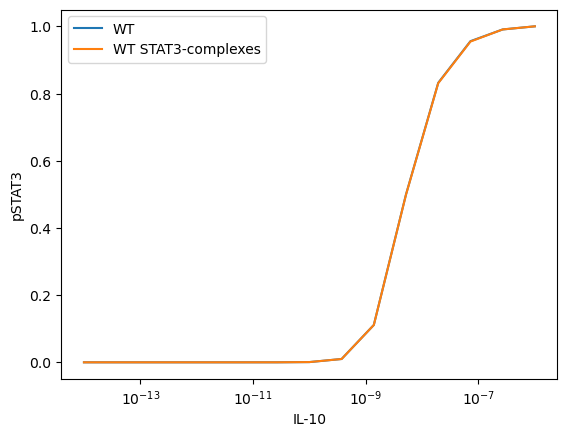

In [10]:
plt.plot(IL_10vec,STAT3_WT/max(STAT3_WT), label="WT")
plt.plot(IL_10vec,STAT3C_WT/max(STAT3C_WT), label="WT STAT3-complexes")
plt.legend(loc="best")
plt.xscale("log")
plt.xlabel("IL-10")
plt.ylabel("pSTAT3")

As can be seen the phosphorylation and desphosphorylation of STAT3 do not affect the behavior of the system -> If we compare the normalized sum of complexes with STAT3 with the normalized free STAT3P they both give very similar values

Next we compare a model with all interactions to one where repeated complexes (ILRA1=ILRA2) are combined, thus cutting by half the number of edges and nodes. As seen above, for STAT3 we don't consider the phosphorylation and desphosphorylation

In [11]:
# Amount of nodes and edges correct
def model_func_simpl_bind(PA,IC):
    Na=6.023e23
    Width_PM = 1e-7 # In dm
    # Initialize model
    Model()
    
    # Compartment
    Compartment(name='EC', parent=None, dimension=3, size=None)
    Compartment(name='Cell_PM', parent=EC, dimension=2, size=None)
    Compartment(name='Cell_CP', parent=Cell_PM, dimension=3, size=None)
    
    # Monomers
    Monomer('ILM')
    Monomer('IL', ['bA1', 'bA2', 'bB1', 'bB2'])
    Monomer('RA', ['bA', 'bSTAT3'])
    Monomer('RB', ['bB'])
    Monomer('STAT3', ['b3','P'], {'P': ['u', 'p']})

    # Parameters
    Parameter('K_ILM_f', PA["k_ILM_f"]/(Na*PA["vol_EC"])*2)
    Parameter('K_ILM_b', PA["k_ILM_b"])
    
    Parameter('K_IL_RA_f', 2*PA["k_IL_RA_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RA_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB_f', 2*PA["k_IL_RB_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RB_b', PA["k_IL_RB_b"])
    
    Parameter('K_IL_RA2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA2_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB2_f', PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RB2_b', PA["k_IL_RB_b"])
    Parameter('K_IL_RA_RB_f', PA["k_IL_RA_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA_RB_b', PA["k_IL_RA_RB_b"])
    
    Parameter('K_IL_RA2_2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM)*(1/2))
    Parameter('K_IL_RB2_2_f', PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM)*(1/2))
    
    Parameter('K_IL_RA2_3_b', PA["k_IL_RA_b"]*(1/2))
    Parameter('K_IL_RA_RB_3_b', PA["k_IL_RA_RB_b"]*(1/2))
    
    Parameter('K_IL_RA2_4_b', PA["k_IL_RA_b"]*2)
    Parameter('K_IL_RA_RB_4_b', PA["k_IL_RA_RB_b"]*2)

    Parameter('K_STAT3_f', PA["k_STAT3_f"]/(Na*PA["vol_cell"]))
    Parameter('K_STAT3_b', PA["k_STAT3_b"])

    Parameter('K_STAT3_2_f', PA["k_STAT3_f"]/(Na*PA["vol_cell"])*2)
    Parameter('K_STAT3_3_f', PA["k_STAT3_f"]/(Na*PA["vol_cell"])*(1/2))
    
    Parameter('K_PHOS', PA["k_PHOS"])
    Parameter('K_PHOS2', 2*PA["k_PHOS"]) 
    Parameter('K_DEPHOS', PA["k_DEPHOS"])
    
    # Complexes and reactions (binding of receptors)
    IL_free = IL(bA1=None, bA2=None, bB1=None, bB2=None)
    ILM_free = ILM()
    Rule('IL_binding', ILM_free + ILM_free | IL_free, *[K_ILM_f, K_ILM_b])
    
    IL_RA1_alone = IL(bA1=1, bA2=None, bB1=None, bB2=None) % RA(bA=1, bSTAT3=None)
    Rule('IL_RA1_alone_binding', IL_free + RA(bA=None, bSTAT3=None)| IL_RA1_alone, *[K_IL_RA_f, K_IL_RA_b])
    IL_RB1_alone = IL(bA1=None, bA2=None, bB1=1, bB2=None) % RB(bB=1)
    Rule('IL_RB1_alone_binding', IL_free + RB(bB=None)| IL_RB1_alone, *[K_IL_RB_f, K_IL_RB_b])
 
    # Binding of second receptors from IL-RA1 complex
    IL_RA1_RA2 = IL(bA1=1, bA2=2, bB1=None, bB2=None) % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=None)
    Rule('IL_RA1_RA2_binding_DB', IL_RA1_alone + RA(bA=None, bSTAT3=None) | IL_RA1_RA2, *[K_IL_RA2_2_f, K_IL_RA2_b])
    IL_RA1_RB1 = IL(bA1=1, bA2=None, bB1=2, bB2=None) % RA(bA=1, bSTAT3=None) % RB(bB=2)
    Rule('IL_RA1_RB1_binding_DB', IL_RA1_alone + RB(bB=None) | IL_RA1_RB1, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    IL_RA1_RB1_S31 = IL(bA1=1, bA2=None, bB1=2, bB2=None) % RA(bA=1, bSTAT3=5) % RB(bB=2) % STAT3(b3=5, P='u')
    Rule('IL_RA1_RB1_unbinding_DB', IL_RA1_RB1_S31 >> IL_RA1_alone + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)
    IL_RA1_RB2 = IL(bA1=1, bA2=None, bB1=None, bB2=2) % RA(bA=1, bSTAT3=None) % RB(bB=2)
    Rule('IL_RA1_RB2_binding_DB', IL_RA1_alone + RB(bB=None) | IL_RA1_RB2, *[K_IL_RB2_f, K_IL_RB2_b])
    
    # Binding of second receptors from IL-RB1 complex
    Rule('IL_RB1_RA1_binding_DB', IL_RB1_alone + RA(bA=None, bSTAT3=None) | IL_RA1_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RB1_RA1_unbinding_DB', IL_RA1_RB1_S31 >> IL_RB1_alone + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    Rule('IL_RB2_RA1_binding_DB', IL_RB1_alone + RA(bA=None, bSTAT3=None) | IL_RA1_RB2, *[K_IL_RA2_f, K_IL_RA2_b])  # IL-RA1-RB2 is the same complex as IL-RA2-RB1
    IL_RB1_RB2 = IL(bA1=None, bA2=None, bB1=1, bB2=2) % RB(bB=1) % RB(bB=2)
    Rule('IL_RB1_RB2_binding_DB', IL_RB1_alone + RB(bB=None) | IL_RB1_RB2, *[K_IL_RB2_2_f, K_IL_RB2_b])
    
    # Binding of third receptors to form IL-RA1-RA2-RB1 complex
    IL_RA1_RA2_RB1 = IL(bA1=1, bA2=2, bB1=3, bB2=None) % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=None) % RB(bB=3)
    Rule('IL_RA1RA1_RB1_binding_TB', IL_RA1_RA2 + RB(bB=None) | IL_RA1_RA2_RB1, *[K_IL_RA_RB_f, K_IL_RA_RB_3_b])
    IL_RA1_RA2_RB1_S31 = IL(bA1=1, bA2=2, bB1=3, bB2=None) % RA(bA=1, bSTAT3=5) % RA(bA=2, bSTAT3=None) % RB(bB=3) % STAT3(b3=5, P='u')
    Rule('IL_RA1RA1_RB1_unbinding_TB', IL_RA1_RA2_RB1_S31 >> IL_RA1_RA2 + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_3_b)
    Rule('IL_RA1RB1_RA2_binding_TB', IL_RA1_RB1 + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RA1RB1_RA2_binding_TB2', IL_RA1_RB1_S31 + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1_S31, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RA1RB2_RA2_binding_TB', IL_RA1_RB2 + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RA1RB2_RA2_unbinding_TB', IL_RA1_RA2_RB1_S31 >> IL_RA1_RB2 + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_b)
    
    # Binding of third receptors to form IL-RA1-RB1-RB2 complex
    IL_RA1_RB1_RB2 = IL(bA1=1, bA2=None, bB1=2, bB2=3) % RA(bA=1, bSTAT3=None) % RB(bB=2) % RB(bB=3)
    IL_RA1_RB1_RB2_S31 = IL(bA1=1, bA2=None, bB1=2, bB2=3) % RA(bA=1, bSTAT3=5) % RB(bB=2) % RB(bB=3) % STAT3(b3=5, P='u')
    Rule('IL_RA1RB1_RB2_binding_TB', IL_RA1_RB1 + RB(bB=None) | IL_RA1_RB1_RB2, *[K_IL_RB2_f, K_IL_RB2_b])
    Rule('IL_RA1RB1_RB2_binding_TB2', IL_RA1_RB1_S31 + RB(bB=None) | IL_RA1_RB1_RB2_S31, *[K_IL_RB2_f, K_IL_RB2_b])
    Rule('IL_RA1RB2_RB1_binding_TB', IL_RA1_RB2 + RB(bB=None) | IL_RA1_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_RA1RB2_RB1_unbinding_TB', IL_RA1_RB1_RB2_S31 >> IL_RA1_RB2 + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)
    Rule('IL_RB1RB2_RA2_binding_TB', IL_RB1_RB2 + RA(bA=None, bSTAT3=None) | IL_RA1_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_3_b])
    Rule('IL_RB1RB2_RA2_unbinding_TB', IL_RA1_RB1_RB2_S31 >> IL_RB1_RB2 + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_3_b)
    
    # Binding of fourth receptor
    IL_RA1_RA2_RB1_RB2 = IL(bA1=1, bA2=2, bB1=3, bB2=4) % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=None) % RB(bB=3) % RB(bB=4)
    IL_RA1_RA2_RB1_RB2_S31 = IL(bA1=1, bA2=2, bB1=3, bB2=4) % RA(bA=1, bSTAT3=5) % RA(bA=2, bSTAT3=None) % RB(bB=3) % RB(bB=4) % STAT3(b3=5, P='u')
    IL_RA1_RA2_RB1_RB2_S31_S32 = IL(bA1=1, bA2=2, bB1=3, bB2=4) % RA(bA=1, bSTAT3=5) % RA(bA=2, bSTAT3=6) % RB(bB=3) % RB(bB=4) % STAT3(b3=5, P='u') % STAT3(b3=6, P='u')

    Rule('IL_RA1RA2RB1_RB2_binding_QB', IL_RA1_RA2_RB1 + RB(bB=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_4_b])
    Rule('IL_RA1RA2RB1_RB2_binding_QB2', IL_RA1_RA2_RB1_S31 + RB(bB=None) | IL_RA1_RA2_RB1_RB2_S31, *[K_IL_RA_RB_f, K_IL_RA_RB_4_b])
    Rule('IL_RA1RA2RB1_RB2_unbinding_QB', IL_RA1_RA2_RB1_RB2_S31_S32 >> IL_RA1_RA2_RB1_S31 + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_4_b)
    Rule('IL_RA1RA2RB1_RB2_unbinding_QB2', IL_RA1_RA2_RB1_RB2_S31 >> IL_RA1_RA2_RB1 + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_4_b) # Maybe
    
    Rule('IL_RA1RB1RB2_RA2_binding_QB', IL_RA1_RB1_RB2 + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_4_b])
    Rule('IL_RA1RB1RB2_RA2_binding_QB2', IL_RA1_RB1_RB2_S31 + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1_RB2_S31, *[K_IL_RA2_f, K_IL_RA2_4_b])
    Rule('IL_RA1RB1RB2_RA2_unbinding_QB', IL_RA1_RA2_RB1_RB2_S31_S32 >> IL_RA1_RB1_RB2_S31 + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_4_b)
    Rule('IL_RA1RB1RB2_RA2_unbinding_QB2', IL_RA1_RA2_RB1_RB2_S31 >> IL_RA1_RB1_RB2 + RA(bA=None, bSTAT3=None) + STAT3(b3=None, P='u'), K_IL_RA2_4_b) # Maybe
    
    # Binding of STAT
    Rule('IL_RA1_RB1_S3_binding', IL_RA1_RB1 + STAT3(b3=None, P='u') | IL_RA1_RB1_S31, *[K_STAT3_f, K_STAT3_b])
    Rule('IL_IL_RA1_RA2_RB1_S3_binding', IL_RA1_RA2_RB1 + STAT3(b3=None, P='u') | IL_RA1_RA2_RB1_S31, *[K_STAT3_f, K_STAT3_b])
    Rule('IL_IL_RA1_RB1_RB2_S3_binding', IL_RA1_RB1_RB2 + STAT3(b3=None, P='u') | IL_RA1_RB1_RB2_S31, *[K_STAT3_f, K_STAT3_b])
    Rule('IL_IL_RA1_RA2_RB1_RB2_S31_binding', IL_RA1_RA2_RB1_RB2 + STAT3(b3=None, P='u') | IL_RA1_RA2_RB1_RB2_S31, *[K_STAT3_2_f, K_STAT3_b])
    Rule('IL_IL_RA1_RA2_RB1_RB2_S31_S32_binding', IL_RA1_RA2_RB1_RB2_S31 + STAT3(b3=None, P='u') | IL_RA1_RA2_RB1_RB2_S31_S32, *[K_STAT3_3_f, K_STAT3_b])
    
    # Initial conditions
    Kd_IL = PA["k_ILM_b"]/(PA["k_ILM_f"]/(Na*PA["vol_EC"]))
    ILM_eq = (-Kd_IL/2 + (Kd_IL**2/4 + 2*Kd_IL*IC["IL0"]*Na*PA["vol_EC"])**(1/2))/2
    ILD_eq = (IC["IL0"]*Na*PA["vol_EC"]-ILM_eq)/2
    Parameter('ILM_0', ILM_eq)
    Initial(ILM() ** EC , ILM_0)
    Parameter('ILD_0', ILD_eq) #IC["IL0"]*Na*PA["vol_EC"])
    Initial(IL(bA1=None, bA2=None, bB1=None, bB2=None) ** EC, ILD_0)
    
    Parameter('RA_0',IC["RA0"])
    Parameter('RB_0',IC["RB0"])
    Initial(RA(bA=None, bSTAT3=None) ** Cell_PM, RA_0)
    Initial(RB(bB=None) ** Cell_PM, RB_0)

    Parameter('STAT_3_0', IC["STAT30"])
    Initial(STAT3(b3=None, P='u') ** Cell_CP, STAT_3_0)
    
    # Simulation
    Observable('ILM_free', ILM() ** EC)
    Observable('IL_free', IL(bA1=None, bA2=None, bB1=None, bB2=None) ** EC)
    Observable('RA_free', RA(bA=None, bSTAT3=None) ** Cell_PM)
    Observable('RB_free', RB(bB=None) ** Cell_PM)
    Observable('S3_free', STAT3(b3=None, P='u') ** Cell_CP)
    
    Observable('IL_RA1', IL(bA1=1, bA2=None, bB1=None, bB2=None) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM)
    Observable('IL_RB1', IL(bA1=None, bA2=None, bB1=1, bB2=None) ** EC % RB(bB=1) ** Cell_PM)
    
    Observable('IL_RA1_RA2', IL(bA1=1, bA2=2, bB1=None, bB2=None) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM)
    Observable('IL_RA1_RB1', IL(bA1=1, bA2=None, bB1=2, bB2=None) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA1_RB2', IL(bA1=1, bA2=None, bB1=None, bB2=2) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RB1_RB2', IL(bA1=None, bA2=None, bB1=1, bB2=2) ** EC % RB(bB=1) ** Cell_PM % RB(bB=2) ** Cell_PM)

    Observable('IL_RA1_RA2_RB1', IL(bA1=1, bA2=2, bB1=3, bB2=None) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1_RB1_RB2', IL(bA1=1, bA2=None, bB1=2, bB2=3) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM)
    
    Observable('IL_RA1_RA2_RB1_RB2', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM)
    
    Observable('IL_RA1_RB1_S31', IL(bA1=1, bA2=None, bB1=2, bB2=None) ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RB(bB=2) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    
    Observable('IL_RA1_RA2_RB1_S31', IL(bA1=1, bA2=2, bB1=3, bB2=None) ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    Observable('IL_RA1_RB1_RB2_S31', IL(bA1=1, bA2=None, bB1=2, bB2=3) ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    
    Observable('IL_RA1_RA2_RB1_RB2_S31', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    Observable('IL_RA1_RA2_RB1_RB2_S31_S32', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RA(bA=2, bSTAT3=6) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP % STAT3(b3=6, P='u') ** Cell_CP)
    
    Observable('STAT3P', STAT3(b3=None, P='p') ** Cell_CP)

    dT, Tf = func_time(IC["IL0"])
    t = np.arange(0,Tf*5,dT/100)
    simulator = ScipyOdeSimulator(model, tspan=t, compiler='python', integrator = 'lsoda').run()
    return simulator.all

In [12]:
start_time = time()
STAT3C_full = []
STAT3C_simpl = []
for IL_10 in IL_10vec:
    IC = {
    "IL0":IL_10,
    "RA0":750,
    "RB0":4323,
    "STAT10" : 477858.2479731492,
    "M0" : 477858.2479731492,
    "STAT30" : 477858.2479731492
    }
    simulator = model_func_full_bind(PA,IC)
    STAT3C_full.append(simulator['IL_RA1_RB1_S31'][-1]+simulator['IL_RA2_RB2_S32'][-1]+simulator['IL_RA1_RA2_RB1_S31'][-1]+simulator['IL_RA1_RA2_RB2_S32'][-1]+simulator['IL_RA1_RB1_RB2_S31'][-1]+simulator['IL_RA2_RB1_RB2_S32'][-1]+simulator['IL_RA1_RA2_RB1_RB2_S31'][-1]+simulator['IL_RA1_RA2_RB1_RB2_S32'][-1]+2*simulator['IL_RA1_RA2_RB1_RB2_S31_S32'][-1])
    simulator = model_func_simpl_bind(PA,IC)
    STAT3C_simpl.append(simulator['IL_RA1_RB1_S31'][-1]+simulator['IL_RA1_RA2_RB1_S31'][-1]+simulator['IL_RA1_RB1_RB2_S31'][-1]+simulator['IL_RA1_RA2_RB1_RB2_S31'][-1]+2*simulator['IL_RA1_RA2_RB1_RB2_S31_S32'][-1])
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 109.698797 seconds


Text(0, 0.5, 'pSTAT3')

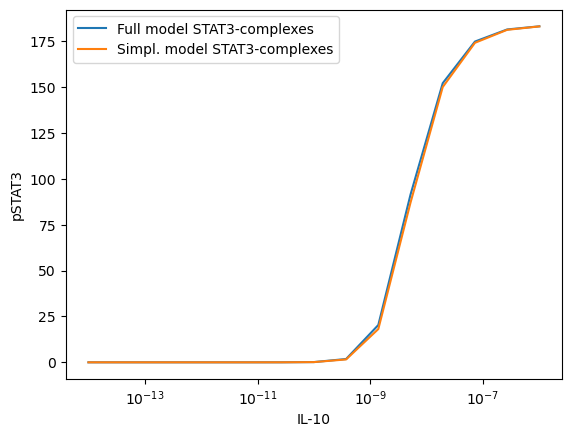

In [13]:
plt.plot(IL_10vec,STAT3C_full, label="Full model STAT3-complexes")
plt.plot(IL_10vec,STAT3C_simpl, label="Simpl. model STAT3-complexes")
plt.legend(loc="best")
plt.xscale("log")
plt.xlabel("IL-10")
plt.ylabel("pSTAT3")

The simplified model allows us to get a very similar behavior than the full model (differences could be due to numerical errors).

However the model is still to large to get the SS through linear franework. Since binding of RB without RA is uncommon, we decide to remove it from the model to further simplify it

In [14]:
# Amount of nodes and edges correct
def model_func_simpl2_bind(PA,IC):
    Na=6.023e23
    Width_PM = 1e-7 # In dm
    # Initialize model
    Model()
    
    # Compartment
    Compartment(name='EC', parent=None, dimension=3, size=None)
    Compartment(name='Cell_PM', parent=EC, dimension=2, size=None)
    Compartment(name='Cell_CP', parent=Cell_PM, dimension=3, size=None)
    
    # Monomers
    Monomer('ILM')
    Monomer('IL', ['bA1', 'bA2', 'bB1', 'bB2'])
    Monomer('RA', ['bA', 'bSTAT3'])
    Monomer('RB', ['bB'])
    Monomer('STAT3', ['b3','P'], {'P': ['u', 'p']})
    

    # Parameters
    Parameter('K_ILM_f', PA["k_ILM_f"]/(Na*PA["vol_EC"])*2)
    Parameter('K_ILM_b', PA["k_ILM_b"])
    
    Parameter('K_IL_RA_f', 2*PA["k_IL_RA_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RA_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB_f', 2*PA["k_IL_RB_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RB_b', PA["k_IL_RB_b"])
    
    Parameter('K_IL_RA2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA2_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB2_f', PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RB2_b', PA["k_IL_RB_b"])
    Parameter('K_IL_RA_RB_f', PA["k_IL_RA_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA_RB_b', PA["k_IL_RA_RB_b"])
    
    Parameter('K_IL_RA2_2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM)*(1/2))
    Parameter('K_IL_RB2_2_f', PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM)*(1/2))
    
    Parameter('K_IL_RA2_3_b', PA["k_IL_RA_b"]*(1/2))
    Parameter('K_IL_RA_RB_3_b', PA["k_IL_RA_RB_b"]*(1/2))
    
    Parameter('K_IL_RA2_4_b', PA["k_IL_RA_b"]*2)
    Parameter('K_IL_RA_RB_4_b', PA["k_IL_RA_RB_b"]*2)

    Parameter('K_STAT3_f', PA["k_STAT3_f"]/(Na*PA["vol_cell"]))
    Parameter('K_STAT3_b', PA["k_STAT3_b"])

    Parameter('K_STAT3_2_f', PA["k_STAT3_f"]/(Na*PA["vol_cell"])*2)
    Parameter('K_STAT3_3_f', PA["k_STAT3_f"]/(Na*PA["vol_cell"])*(1/2))
    
    
    # Complexes and reactions (binding of receptors)
    IL_free = IL(bA1=None, bA2=None, bB1=None, bB2=None)
    ILM_free = ILM()
    Rule('IL_binding', ILM_free + ILM_free | IL_free, *[K_ILM_f, K_ILM_b])
    
    IL_RA1_alone = IL(bA1=1, bA2=None, bB1=None, bB2=None) % RA(bA=1, bSTAT3=None)
    Rule('IL_RA1_alone_binding', IL_free + RA(bA=None, bSTAT3=None)| IL_RA1_alone, *[K_IL_RA_f, K_IL_RA_b])

    # Binding of second receptors from IL-RA1 complex
    IL_RA1_RA2 = IL(bA1=1, bA2=2, bB1=None, bB2=None) % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=None)
    Rule('IL_RA1_RA2_binding_DB', IL_RA1_alone + RA(bA=None, bSTAT3=None) | IL_RA1_RA2, *[K_IL_RA2_2_f, K_IL_RA2_b])
    IL_RA1_RB1 = IL(bA1=1, bA2=None, bB1=2, bB2=None) % RA(bA=1, bSTAT3=None) % RB(bB=2)
    Rule('IL_RA1_RB1_binding_DB', IL_RA1_alone + RB(bB=None) | IL_RA1_RB1, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    IL_RA1_RB1_S31 = IL(bA1=1, bA2=None, bB1=2, bB2=None) % RA(bA=1, bSTAT3=5) % RB(bB=2) % STAT3(b3=5, P='u')
    Rule('IL_RA1_RB1_unbinding_DB', IL_RA1_RB1_S31 >> IL_RA1_alone + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_b)
    
    # Binding of third receptors to form IL-RA1-RA2-RB1 complex
    IL_RA1_RA2_RB1 = IL(bA1=1, bA2=2, bB1=3, bB2=None) % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=None) % RB(bB=3)
    Rule('IL_RA1RA1_RB1_binding_TB', IL_RA1_RA2 + RB(bB=None) | IL_RA1_RA2_RB1, *[K_IL_RA_RB_f, K_IL_RA_RB_3_b])
    IL_RA1_RA2_RB1_S31 = IL(bA1=1, bA2=2, bB1=3, bB2=None) % RA(bA=1, bSTAT3=5) % RA(bA=2, bSTAT3=None) % RB(bB=3) % STAT3(b3=5, P='u')
    Rule('IL_RA1RA1_RB1_unbinding_TB', IL_RA1_RA2_RB1_S31 >> IL_RA1_RA2 + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_3_b)
    Rule('IL_RA1RB1_RA2_binding_TB', IL_RA1_RB1 + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RA1RB1_RA2_binding_TB2', IL_RA1_RB1_S31 + RA(bA=None, bSTAT3=None) | IL_RA1_RA2_RB1_S31, *[K_IL_RA2_f, K_IL_RA2_b])
    
    
    # Binding of fourth receptor
    IL_RA1_RA2_RB1_RB2 = IL(bA1=1, bA2=2, bB1=3, bB2=4) % RA(bA=1, bSTAT3=None) % RA(bA=2, bSTAT3=None) % RB(bB=3) % RB(bB=4)
    IL_RA1_RA2_RB1_RB2_S31 = IL(bA1=1, bA2=2, bB1=3, bB2=4) % RA(bA=1, bSTAT3=5) % RA(bA=2, bSTAT3=None) % RB(bB=3) % RB(bB=4) % STAT3(b3=5, P='u')
    IL_RA1_RA2_RB1_RB2_S31_S32 = IL(bA1=1, bA2=2, bB1=3, bB2=4) % RA(bA=1, bSTAT3=5) % RA(bA=2, bSTAT3=6) % RB(bB=3) % RB(bB=4) % STAT3(b3=5, P='u') % STAT3(b3=6, P='u')

    Rule('IL_RA1RA2RB1_RB2_binding_QB', IL_RA1_RA2_RB1 + RB(bB=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_4_b])
    Rule('IL_RA1RA2RB1_RB2_binding_QB2', IL_RA1_RA2_RB1_S31 + RB(bB=None) | IL_RA1_RA2_RB1_RB2_S31, *[K_IL_RA_RB_f, K_IL_RA_RB_4_b])
    Rule('IL_RA1RA2RB1_RB2_unbinding_QB', IL_RA1_RA2_RB1_RB2_S31_S32 >> IL_RA1_RA2_RB1_S31 + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_4_b)
    Rule('IL_RA1RA2RB1_RB2_unbinding_QB2', IL_RA1_RA2_RB1_RB2_S31 >> IL_RA1_RA2_RB1 + RB(bB=None) + STAT3(b3=None, P='u'), K_IL_RA_RB_4_b) # Maybe
    
    # Binding of STAT
    Rule('IL_RA1_RB1_S3_binding', IL_RA1_RB1 + STAT3(b3=None, P='u') | IL_RA1_RB1_S31, *[K_STAT3_f, K_STAT3_b])
    Rule('IL_IL_RA1_RA2_RB1_S3_binding', IL_RA1_RA2_RB1 + STAT3(b3=None, P='u') | IL_RA1_RA2_RB1_S31, *[K_STAT3_f, K_STAT3_b])
    Rule('IL_IL_RA1_RA2_RB1_RB2_S31_binding', IL_RA1_RA2_RB1_RB2 + STAT3(b3=None, P='u') | IL_RA1_RA2_RB1_RB2_S31, *[K_STAT3_2_f, K_STAT3_b])
    Rule('IL_IL_RA1_RA2_RB1_RB2_S31_S32_binding', IL_RA1_RA2_RB1_RB2_S31 + STAT3(b3=None, P='u') | IL_RA1_RA2_RB1_RB2_S31_S32, *[K_STAT3_3_f, K_STAT3_b])
    
    # Initial conditions
    Kd_IL = PA["k_ILM_b"]/(PA["k_ILM_f"]/(Na*PA["vol_EC"]))
    ILM_eq = (-Kd_IL/2 + (Kd_IL**2/4 + 2*Kd_IL*IC["IL0"]*Na*PA["vol_EC"])**(1/2))/2
    ILD_eq = (IC["IL0"]*Na*PA["vol_EC"]-ILM_eq)/2
    Parameter('ILM_0', ILM_eq)
    Initial(ILM() ** EC , ILM_0)
    Parameter('ILD_0', ILD_eq) #IC["IL0"]*Na*PA["vol_EC"])
    Initial(IL(bA1=None, bA2=None, bB1=None, bB2=None) ** EC, ILD_0)
    
    Parameter('RA_0',IC["RA0"])
    Parameter('RB_0',IC["RB0"])
    Initial(RA(bA=None, bSTAT3=None) ** Cell_PM, RA_0)
    Initial(RB(bB=None) ** Cell_PM, RB_0)

    Parameter('STAT_3_0', IC["STAT30"])
    Initial(STAT3(b3=None, P='u') ** Cell_CP, STAT_3_0)
    
    # Simulation
    Observable('ILM_free', ILM() ** EC)
    Observable('IL_free', IL(bA1=None, bA2=None, bB1=None, bB2=None) ** EC)
    Observable('RA_free', RA(bA=None, bSTAT3=None) ** Cell_PM)
    Observable('RB_free', RB(bB=None) ** Cell_PM)
    Observable('S3_free', STAT3(b3=None, P='u') ** Cell_CP)
    
    Observable('IL_RA1', IL(bA1=1, bA2=None, bB1=None, bB2=None) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM)
    Observable('IL_RB1', IL(bA1=None, bA2=None, bB1=1, bB2=None) ** EC % RB(bB=1) ** Cell_PM)
    
    Observable('IL_RA1_RA2', IL(bA1=1, bA2=2, bB1=None, bB2=None) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM)
    Observable('IL_RA1_RB1', IL(bA1=1, bA2=None, bB1=2, bB2=None) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA1_RB2', IL(bA1=1, bA2=None, bB1=None, bB2=2) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RB1_RB2', IL(bA1=None, bA2=None, bB1=1, bB2=2) ** EC % RB(bB=1) ** Cell_PM % RB(bB=2) ** Cell_PM)

    Observable('IL_RA1_RA2_RB1', IL(bA1=1, bA2=2, bB1=3, bB2=None) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM)
    
    Observable('IL_RA1_RA2_RB1_RB2', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=None) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM)
    
    Observable('IL_RA1_RB1_S31', IL(bA1=1, bA2=None, bB1=2, bB2=None) ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RB(bB=2) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    
    Observable('IL_RA1_RA2_RB1_S31', IL(bA1=1, bA2=2, bB1=3, bB2=None) ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    
    Observable('IL_RA1_RA2_RB1_RB2_S31', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RA(bA=2, bSTAT3=None) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP)
    Observable('IL_RA1_RA2_RB1_RB2_S31_S32', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, bSTAT3=5) ** Cell_PM % RA(bA=2, bSTAT3=6) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM % STAT3(b3=5, P='u') ** Cell_CP % STAT3(b3=6, P='u') ** Cell_CP)
    
    Observable('STAT3P', STAT3(b3=None, P='p') ** Cell_CP)

    dT, Tf = func_time(IC["IL0"])
    t = np.arange(0,Tf*5,dT/100)
    simulator = ScipyOdeSimulator(model, tspan=t, compiler='python', integrator = 'lsoda').run()
    return simulator.all

In [15]:
start_time = time()
STAT3C_full = []
STAT3C_simpl = []
for IL_10 in IL_10vec:
    IC = {
    "IL0":IL_10,
    "RA0":750,
    "RB0":4323,
    "STAT10" : 477858.2479731492,
    "M0" : 477858.2479731492,
    "STAT30" : 477858.2479731492
    }
    simulator = model_func_full_bind(PA,IC)
    STAT3C_full.append(simulator['IL_RA1_RB1_S31'][-1]+simulator['IL_RA2_RB2_S32'][-1]+simulator['IL_RA1_RA2_RB1_S31'][-1]+simulator['IL_RA1_RA2_RB2_S32'][-1]+simulator['IL_RA1_RB1_RB2_S31'][-1]+simulator['IL_RA2_RB1_RB2_S32'][-1]+simulator['IL_RA1_RA2_RB1_RB2_S31'][-1]+simulator['IL_RA1_RA2_RB1_RB2_S32'][-1]+2*simulator['IL_RA1_RA2_RB1_RB2_S31_S32'][-1])
    simulator = model_func_simpl2_bind(PA,IC)
    STAT3C_simpl.append(simulator['IL_RA1_RB1_S31'][-1]+simulator['IL_RA1_RA2_RB1_S31'][-1]+simulator['IL_RA1_RA2_RB1_RB2_S31'][-1]+2*simulator['IL_RA1_RA2_RB1_RB2_S31_S32'][-1])
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 110.323936 seconds


Text(0, 0.5, 'pSTAT3')

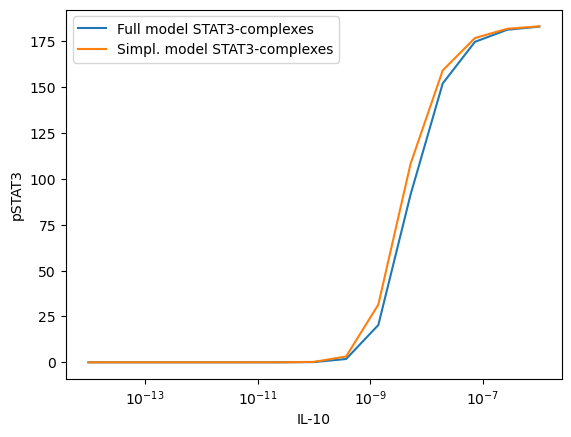

In [16]:
plt.plot(IL_10vec,STAT3C_full, label="Full model STAT3-complexes")
plt.plot(IL_10vec,STAT3C_simpl, label="Simpl. model STAT3-complexes")
plt.legend(loc="best")
plt.xscale("log")
plt.xlabel("IL-10")
plt.ylabel("pSTAT3")

At binding rates around 10/100 times higher than WT measured values the simplified model still behaves very similar to the non-simplified one -> We use it to find the SS 

Using the simplified model, we got the SS solution using linear framework. Now we use the SS solution to check if it still behaves like the non-simplified model.

In [17]:
def simulate_model_STAT3(PA,IC):
    def STAT3_model(x):
        RA = x[0]
        RB = x[1]
        S3 = x[2]
        IL10M = x[3]
        
        RA_expr = -IL10M0*(2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*RA*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 144*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 100*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 96*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 60*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 34*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 81*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 72*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 52*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 31*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 25*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 59*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 142*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 44*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 29*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 96*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 60*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 8*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 52*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 132*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 22*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 92*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 94*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 52*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 28*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 75*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 68*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 51*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 27*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 22*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 17*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 50*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 53*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 126*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 28*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 43*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 25*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 92*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 54*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 12*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 8*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 4*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 8*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 35*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 4*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 9*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 26*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 29*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 21*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 6*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 4*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 8*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2))/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*RA*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 144*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 100*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 96*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 60*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 34*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 81*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 72*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 52*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 31*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 25*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 59*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 142*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 44*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 29*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 96*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 60*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 52*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 132*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 22*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 92*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 94*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 52*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 28*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 75*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 68*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 51*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 27*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 22*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 17*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 50*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 53*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 126*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 28*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 43*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 25*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 92*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 54*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 12*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 8*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 4*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 8*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 35*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 4*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 9*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 26*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 29*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 21*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 6*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 4*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 8*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2) + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4)) - RA + RA0
        RB_expr = -IL10M0*(2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 144*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 100*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 96*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 60*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 34*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 81*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 72*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 52*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 31*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 25*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 59*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 142*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 44*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 29*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 96*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 60*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 52*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 132*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 22*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 92*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 94*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 52*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 28*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 75*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 68*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 51*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 27*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 22*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 17*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 50*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 53*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 126*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 28*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 43*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 25*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 92*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 54*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 12*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 8*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 4*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 8*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 35*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 4*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 9*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 26*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 29*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 21*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 6*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 4*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 8*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2))/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*RA*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 144*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 100*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 96*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 60*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 34*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 81*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 72*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 52*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 31*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 25*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 59*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 142*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 44*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 29*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 96*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 60*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 52*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 132*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 22*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 92*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 94*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 52*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 28*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 75*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 68*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 51*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 27*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 22*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 17*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 50*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 53*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 126*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 28*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 43*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 25*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 92*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 54*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 12*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 8*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 4*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 8*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 35*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 4*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 9*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 26*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 29*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 21*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 6*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 4*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 8*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2) + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4)) - RB + RB0
        S3_expr = -IL10M0*(2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2))/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*RA*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 144*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 100*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 96*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 60*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 34*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 81*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 72*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 52*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 31*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 25*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 59*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 142*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 44*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 29*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 96*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 60*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 52*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 132*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 22*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 92*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 94*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 52*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 28*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 75*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 68*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 51*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 27*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 22*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 17*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 50*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 53*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 126*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 28*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 43*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 25*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 92*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 54*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 12*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 8*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 4*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 8*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 35*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 4*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 9*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 26*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 29*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 21*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 6*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 4*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 8*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2) + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4)) - S3 + S30
        ILM_expr = -IL10M - IL10M0*(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*RA*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 144*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 100*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 96*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 60*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 34*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 81*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 72*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 52*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 31*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 25*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 59*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 142*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 44*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 29*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 96*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 60*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 52*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 132*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 22*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 92*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 94*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 52*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 28*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 75*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 68*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 51*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 27*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 22*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 17*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 50*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 53*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 126*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 28*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 43*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 25*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 92*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 54*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 12*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 8*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 4*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 8*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 35*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 4*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 9*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 26*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 29*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 21*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 6*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 4*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 8*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2))/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*RA*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 144*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 100*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 96*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 60*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 34*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 81*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 72*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 52*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 31*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 25*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 59*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 142*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 44*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 29*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 96*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 60*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 52*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 132*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 22*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 92*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 94*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 52*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 28*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 75*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 68*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 51*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 27*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 22*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 17*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 50*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 53*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 126*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 28*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 43*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 25*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 92*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 54*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 12*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 8*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 4*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 8*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 35*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 4*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 9*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 26*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 29*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 21*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 6*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 4*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 8*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2) + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4)) + IL10M0
        return [RA_expr,RB_expr,S3_expr,ILM_expr]
    
    def SS_STAT3_model():
        ILRA1RB1S31 = -IL10M0*(4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2))/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*RA*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 144*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 100*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 96*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 60*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 34*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 81*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 72*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 52*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 31*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 25*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 59*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 142*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 44*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 29*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 96*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 60*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 52*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 132*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 22*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 92*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 94*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 52*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 28*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 75*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 68*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 51*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 27*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 22*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 17*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 50*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 53*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 126*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 28*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 43*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 25*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 92*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 54*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 12*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 8*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 4*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 8*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 35*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 4*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 9*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 26*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 29*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 21*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 6*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 4*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 8*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2) + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4)) - S3 + S30
        ILRA1RA2RB1S31 = -IL10M0*(2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2))/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*RA*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 144*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 100*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 96*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 60*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 34*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 81*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 72*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 52*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 31*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 25*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 59*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 142*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 44*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 29*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 96*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 60*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 52*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 132*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 22*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 92*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 94*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 52*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 28*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 75*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 68*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 51*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 27*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 22*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 17*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 50*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 53*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 126*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 28*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 43*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 25*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 92*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 54*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 12*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 8*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 4*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 8*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 35*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 4*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 9*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 26*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 29*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 21*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 6*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 4*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 8*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2) + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4)) - S3 + S30
        ILRA1RA2RB1RB2S31 = -IL10M0*(2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2))/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*RA*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 144*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 100*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 96*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 60*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 34*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 81*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 72*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 52*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 31*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 25*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 59*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 142*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 44*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 29*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 96*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 60*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 52*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 132*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 22*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 92*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 94*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 52*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 28*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 75*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 68*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 51*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 27*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 22*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 17*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 50*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 53*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 126*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 28*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 43*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 25*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 92*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 54*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 12*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 8*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 4*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 8*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 35*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 4*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 9*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 26*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 29*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 21*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 6*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 4*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 8*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2) + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4)) - S3 + S30
        ILRA1RA2RB1RB2S31S32 = -IL10M0*(2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2))/(2*(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*RA*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA*RB*S3*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 16*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 54*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 34*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 43*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 54*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 42*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 21*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 24*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 22*K_IL_RA_RB_b**3*K_STAT3_b + 25*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 52*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 13*K_IL_RA_RB_b**2*K_STAT3_b**2 + 34*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 76*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 68*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 144*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 100*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 96*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 60*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 32*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 34*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 81*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 72*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 52*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 31*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 25*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 66*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 59*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 19*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 142*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 44*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 29*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 96*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 60*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 16*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_STAT3_f*RA**2*RB*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_b**2 + 8*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 3*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 43*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 15*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 42*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 21*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA2_b*K_STAT3_b**3 + 10*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 4*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 11*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 3*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + K_IL_RA2_f*K_STAT3_b**3*RA + 5*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 5*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**4 + 20*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 14*K_IL_RA_RB_b**3*K_STAT3_b + 17*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 34*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 39*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 7*K_IL_RA_RB_b**2*K_STAT3_b**2 + 19*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 10*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 41*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 21*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + K_IL_RA_RB_b*K_STAT3_b**3 + 5*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 5*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 6*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 2*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_b**3*RB + 10*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 10*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 16*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 52*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 68*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 132*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 22*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 92*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 94*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 52*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 28*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA2_b*K_STAT3_b**4 + 20*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 8*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 26*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 42*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 75*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 68*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 51*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 27*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 22*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 10*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 10*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 17*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 50*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 53*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 10*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 126*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 28*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 43*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 25*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 92*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 54*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 10*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 10*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 12*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 8*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 20*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 20*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f**2*RA**2*RB**2*S3**2*(8*K_IL_RA2_b**2*K_IL_RA_RB_b + 4*K_IL_RA2_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_STAT3_f*S3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f*RA*S3 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**2 + 8*K_IL_RA2_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_f**2*S3**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_f*RA**2*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 7*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*RA + 4*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_f**2*RA*S3**2 + 3*K_IL_RA_RB_b**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 5*K_IL_RA_RB_b**2*K_STAT3_b + 5*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2 + 4*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_STAT3_f*RA**2*RB**2*S3*(16*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**2 + 4*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f*S3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f*RA*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b**3 + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b + 24*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**3 + 8*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**2*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f*RA**2*S3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 22*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 15*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**3*RA + 4*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA_RB_b**4 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 13*K_IL_RA_RB_b**3*K_STAT3_b + 10*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 24*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 9*K_IL_RA_RB_b**2*K_STAT3_b**2 + 13*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**3 + 4*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 4*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 8*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 4*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 2*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 35*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 4*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 2*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 9*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 26*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 29*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 66*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 21*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 6*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 4*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 2*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 4*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 8*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 4*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2) + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(32*K_IL_RA2_b**2*K_IL_RA_RB_b**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_b + 68*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_STAT3_f*S3 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b**2 + 76*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*S3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_b**3 + 20*K_IL_RA2_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 20*K_IL_RA2_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 4*K_IL_RA2_b**2*K_STAT3_f**3*S3**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*RA + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 72*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*RA + 84*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f*RA*S3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*RA + 106*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA*S3 + 58*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**2*RA*S3**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**3*RA + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f*RA*S3 + 30*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_STAT3_f**3*RA*S3**3 + 32*K_IL_RA2_b*K_IL_RA_RB_b**4 + 48*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RB + 88*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_b + 100*K_IL_RA2_b*K_IL_RA_RB_b**3*K_STAT3_f*S3 + 88*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RB + 116*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 84*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b**2 + 200*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*S3 + 108*K_IL_RA2_b*K_IL_RA_RB_b**2*K_STAT3_f**2*S3**2 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RB + 140*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 76*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**3 + 124*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*S3 + 136*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*S3**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_STAT3_f**3*S3**3 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 40*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA2_b*K_STAT3_b**4 + 24*K_IL_RA2_b*K_STAT3_b**3*K_STAT3_f*S3 + 40*K_IL_RA2_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 24*K_IL_RA2_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 4*K_IL_RA2_b*K_STAT3_f**4*S3**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_b*RA**2 + 25*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_STAT3_f*RA**2*S3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f*RA**2*RB*S3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b**2*RA**2 + 34*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f*RA**2*S3 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b**2*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA**2*RB*S3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_STAT3_f**2*RA**2*RB*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_b**3*RA**2 + 10*K_IL_RA2_f**2*K_STAT3_b**2*K_STAT3_f*RA**2*S3 + 10*K_IL_RA2_f**2*K_STAT3_b*K_STAT3_f**2*RA**2*S3**2 + 2*K_IL_RA2_f**2*K_STAT3_f**3*RA**2*S3**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**4*RA + 32*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*RA*RB + 52*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_b*RA + 58*K_IL_RA2_f*K_IL_RA_RB_b**3*K_STAT3_f*RA*S3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 68*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*RA*RB + 90*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f*RA*RB*S3 + 48*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b**2*RA + 115*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f*RA*S3 + 63*K_IL_RA2_f*K_IL_RA_RB_b**2*K_STAT3_f**2*RA*S3**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*RA*RB**2 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f*RA*RB**2*S3 + 38*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*RA*RB + 108*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RA*RB*S3 + 58*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**2*RA*RB*S3**2 + 17*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**3*RA + 67*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f*RA*S3 + 73*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**2*RA*S3**2 + 23*K_IL_RA2_f*K_IL_RA_RB_b*K_STAT3_f**3*RA*S3**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RA*RB**2*S3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_STAT3_f**2*RA*RB**2*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**3*RA*RB + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RA*RB*S3 + 30*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RA*RB*S3**2 + 6*K_IL_RA2_f*K_IL_RA_RB_f*K_STAT3_f**3*RA*RB*S3**3 + 2*K_IL_RA2_f*K_STAT3_b**4*RA + 12*K_IL_RA2_f*K_STAT3_b**3*K_STAT3_f*RA*S3 + 20*K_IL_RA2_f*K_STAT3_b**2*K_STAT3_f**2*RA*S3**2 + 12*K_IL_RA2_f*K_STAT3_b*K_STAT3_f**3*RA*S3**3 + 2*K_IL_RA2_f*K_STAT3_f**4*RA*S3**4 + 8*K_IL_RA_RB_b**5 + 24*K_IL_RA_RB_b**4*K_IL_RA_RB_f*RB + 30*K_IL_RA_RB_b**4*K_STAT3_b + 33*K_IL_RA_RB_b**4*K_STAT3_f*S3 + 16*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*RB**2 + 76*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_b*RB + 90*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_STAT3_f*RB*S3 + 35*K_IL_RA_RB_b**3*K_STAT3_b**2 + 81*K_IL_RA_RB_b**3*K_STAT3_b*K_STAT3_f*S3 + 44*K_IL_RA_RB_b**3*K_STAT3_f**2*S3**2 + 32*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_b*RB**2 + 48*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_STAT3_f*RB**2*S3 + 80*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b**2*RB + 194*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f*RB*S3 + 106*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_STAT3_f**2*RB*S3**2 + 15*K_IL_RA_RB_b**2*K_STAT3_b**3 + 57*K_IL_RA_RB_b**2*K_STAT3_b**2*K_STAT3_f*S3 + 63*K_IL_RA_RB_b**2*K_STAT3_b*K_STAT3_f**2*S3**2 + 21*K_IL_RA_RB_b**2*K_STAT3_f**3*S3**3 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b**2*RB**2 + 64*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f*RB**2*S3 + 36*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_STAT3_f**2*RB**2*S3**2 + 32*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**3*RB + 124*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f*RB*S3 + 136*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**2*RB*S3**2 + 44*K_IL_RA_RB_b*K_IL_RA_RB_f*K_STAT3_f**3*RB*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_b**4 + 12*K_IL_RA_RB_b*K_STAT3_b**3*K_STAT3_f*S3 + 20*K_IL_RA_RB_b*K_STAT3_b**2*K_STAT3_f**2*S3**2 + 12*K_IL_RA_RB_b*K_STAT3_b*K_STAT3_f**3*S3**3 + 2*K_IL_RA_RB_b*K_STAT3_f**4*S3**4 + 4*K_IL_RA_RB_f**2*K_STAT3_b**3*RB**2 + 20*K_IL_RA_RB_f**2*K_STAT3_b**2*K_STAT3_f*RB**2*S3 + 20*K_IL_RA_RB_f**2*K_STAT3_b*K_STAT3_f**2*RB**2*S3**2 + 4*K_IL_RA_RB_f**2*K_STAT3_f**3*RB**2*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_b**4*RB + 24*K_IL_RA_RB_f*K_STAT3_b**3*K_STAT3_f*RB*S3 + 40*K_IL_RA_RB_f*K_STAT3_b**2*K_STAT3_f**2*RB*S3**2 + 24*K_IL_RA_RB_f*K_STAT3_b*K_STAT3_f**3*RB*S3**3 + 4*K_IL_RA_RB_f*K_STAT3_f**4*RB*S3**4))) - S3/2 + S30/2
        return ILRA1RB1S31 + ILRA1RA2RB1S31 + ILRA1RA2RB1RB2S31 + 2*ILRA1RA2RB1RB2S31S32
    
    # Get parameters
    Na=6.023e23
    Width_PM = 1e-7 # In dm
    K_ILM_f = PA["k_ILM_f"]/(Na*PA["vol_EC"])
    K_ILM_b = PA["k_ILM_b"]
    K_IL_RA_f = PA["k_IL_RA_f"]/(Na*PA["vol_EC"])
    K_IL_RA_b = PA["k_IL_RA_b"]
    K_IL_RB_f = PA["k_IL_RB_f"]/(Na*PA["vol_EC"])
    K_IL_RB_b = PA["k_IL_RB_b"]
    K_IL_RA2_f = PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM)
    K_IL_RA2_b = PA["k_IL_RA_b"]
    K_IL_RB2_f = PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM)
    K_IL_RB2_b = PA["k_IL_RB_b"]
    K_IL_RA_RB_f = PA["k_IL_RA_RB_f"]/(Na*PA["surf_cell"]*Width_PM)
    K_IL_RA_RB_b = PA["k_IL_RA_RB_b"]
    K_STAT3_f = PA["k_STAT3_f"]/(Na*PA["vol_cell"])
    K_STAT3_b = PA["k_STAT3_b"]

    # Get IC
    IL10M0 = IC["IL0"]*Na*PA["vol_EC"]
    RA0 = IC["RA0"]
    RB0 = IC["RB0"]
    S30 = IC["STAT30"]

    result = least_squares(ftol=1e-8,gtol=1e-8, method='dogbox',fun=STAT3_model, x0=[RA0/2,RB0/2,S30/2,IL10M0/2],bounds=([0,0,0,0],[RA0,RB0,S30,IC["IL0"]*Na*PA["vol_EC"]]))
    RA,RB,S3,IL10M = result.x

    return SS_STAT3_model()

In [18]:
start_time = time()
STAT3C_simpl_LF = []
for IL_10 in IL_10vec:
    IC = {
    "IL0":IL_10,
    "RA0":750,
    "RB0":4323,
    "STAT10" : 477858.2479731492,
    "M0" : 477858.2479731492,
    "STAT30" : 477858.2479731492
    }
    STAT3C_simpl_LF.append(simulate_model_STAT3(PA,IC))

end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 1.011074 seconds


Text(0, 0.5, 'pSTAT3')

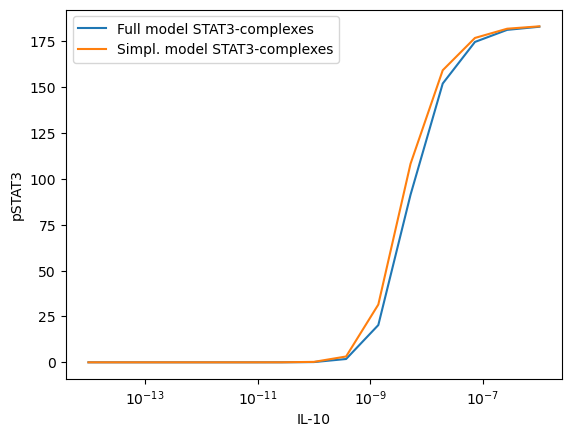

In [19]:
plt.plot(IL_10vec,STAT3C_full, label="Full model STAT3-complexes")
plt.plot(IL_10vec,STAT3C_simpl_LF, label="Simpl. model STAT3-complexes")
plt.legend(loc="best")
plt.xscale("log")
plt.xlabel("IL-10")
plt.ylabel("pSTAT3")

LF of the simplified model behaves the same as the simualtions done until reaching the SS.